In [4]:
print("Proje  : Coimbra Meme Kanseri Teşhisi")
print("Kapsam : SVM, Lojistik Regresyon, ANN + Feature Engineering")
print("Veri   : dataR2.csv  |  116 örnek, 9 özellik → Feature Engineering ile genişletildi")
print("Referans: Patrício et al. (2018) - Breast Cancer Coimbra, UCI ML Repository #451")

Proje  : Coimbra Meme Kanseri Teşhisi
Kapsam : SVM, Lojistik Regresyon, ANN + Feature Engineering
Veri   : dataR2.csv  |  116 örnek, 9 özellik → Feature Engineering ile genişletildi
Referans: Patrício et al. (2018) - Breast Cancer Coimbra, UCI ML Repository #451


In [5]:
# BÖLÜM 1: KÜTÜPHANELER

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid')
np.random.seed(42)
print("Tüm kütüphaneler başarıyla yüklendi.")

Tüm kütüphaneler başarıyla yüklendi.


In [6]:
# BÖLÜM 2: VERİ YÜKLEME VE İLK İNCELEME

df = pd.read_csv('dataR2.csv')
df_raw = df.copy()
df['Classification'] = df['Classification'].replace({1: 0, 2: 1})

print(f"Veri seti boyutu  : {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"Sütunlar          : {list(df.columns)}")
print(f"\nSınıf Dağılımı (0=Sağlıklı, 1=Hasta):\n{df['Classification'].value_counts().to_string()}")
print(f"\nEksik Değer: {df.isnull().sum().sum()}")

Veri seti boyutu  : 116 satır × 10 sütun
Sütunlar          : ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1', 'Classification']

Sınıf Dağılımı (0=Sağlıklı, 1=Hasta):
Classification
1    64
0    52

Eksik Değer: 0


In [7]:
print("İstatistiksel Özet:")
display(df.describe().round(3))

İstatistiksel Özet:


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000
mean,57.302,27.582,97.793,10.012,2.695,26.615,10.181,14.726,534.647,0.552
std,16.113,5.020,22.525,10.068,3.642,19.183,6.843,12.391,345.913,0.499
min,24.000,18.370,60.000,2.432,0.467,4.311,1.656,3.210,45.843,0.000
25%,45.000,22.973,85.750,4.359,0.918,12.314,5.474,6.882,269.978,0.000
50%,56.000,27.662,92.000,5.924,1.381,20.271,8.353,10.828,471.322,1.000
75%,71.000,31.241,102.000,11.189,2.858,37.378,11.816,17.755,700.085,1.000
max,89.000,38.579,201.000,58.460,25.050,90.280,38.040,82.100,1698.440,1.000


In [8]:
display(df.head())

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,0
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


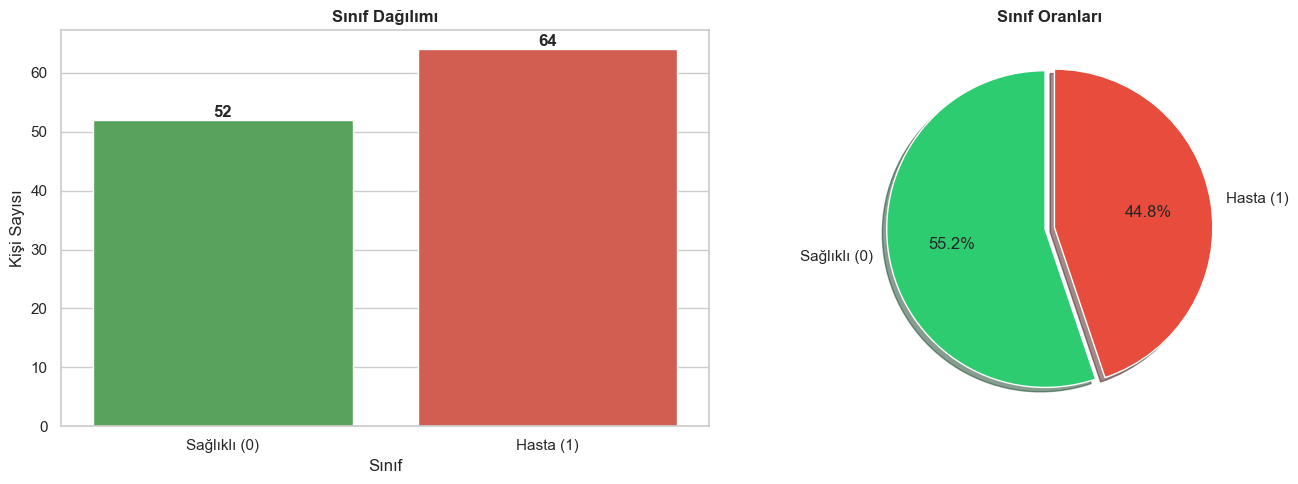

In [9]:
# BÖLÜM 3: KEŞİFSEL VERİ ANALİZİ (EDA)

# Sınıf dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = sns.countplot(x='Classification', data=df,
                   palette=['#4CAF50','#E74C3C'], ax=axes[0])
axes[0].set_xticklabels(['Sağlıklı (0)', 'Hasta (1)'])
axes[0].set_title('Sınıf Dağılımı', fontweight='bold')
axes[0].set_xlabel('Sınıf'); axes[0].set_ylabel('Kişi Sayısı')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
sinif_say = df['Classification'].value_counts()
axes[1].pie(sinif_say, labels=['Sağlıklı (0)','Hasta (1)'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.03,0.03), shadow=True)
axes[1].set_title('Sınıf Oranları', fontweight='bold')
plt.tight_layout(); plt.show()

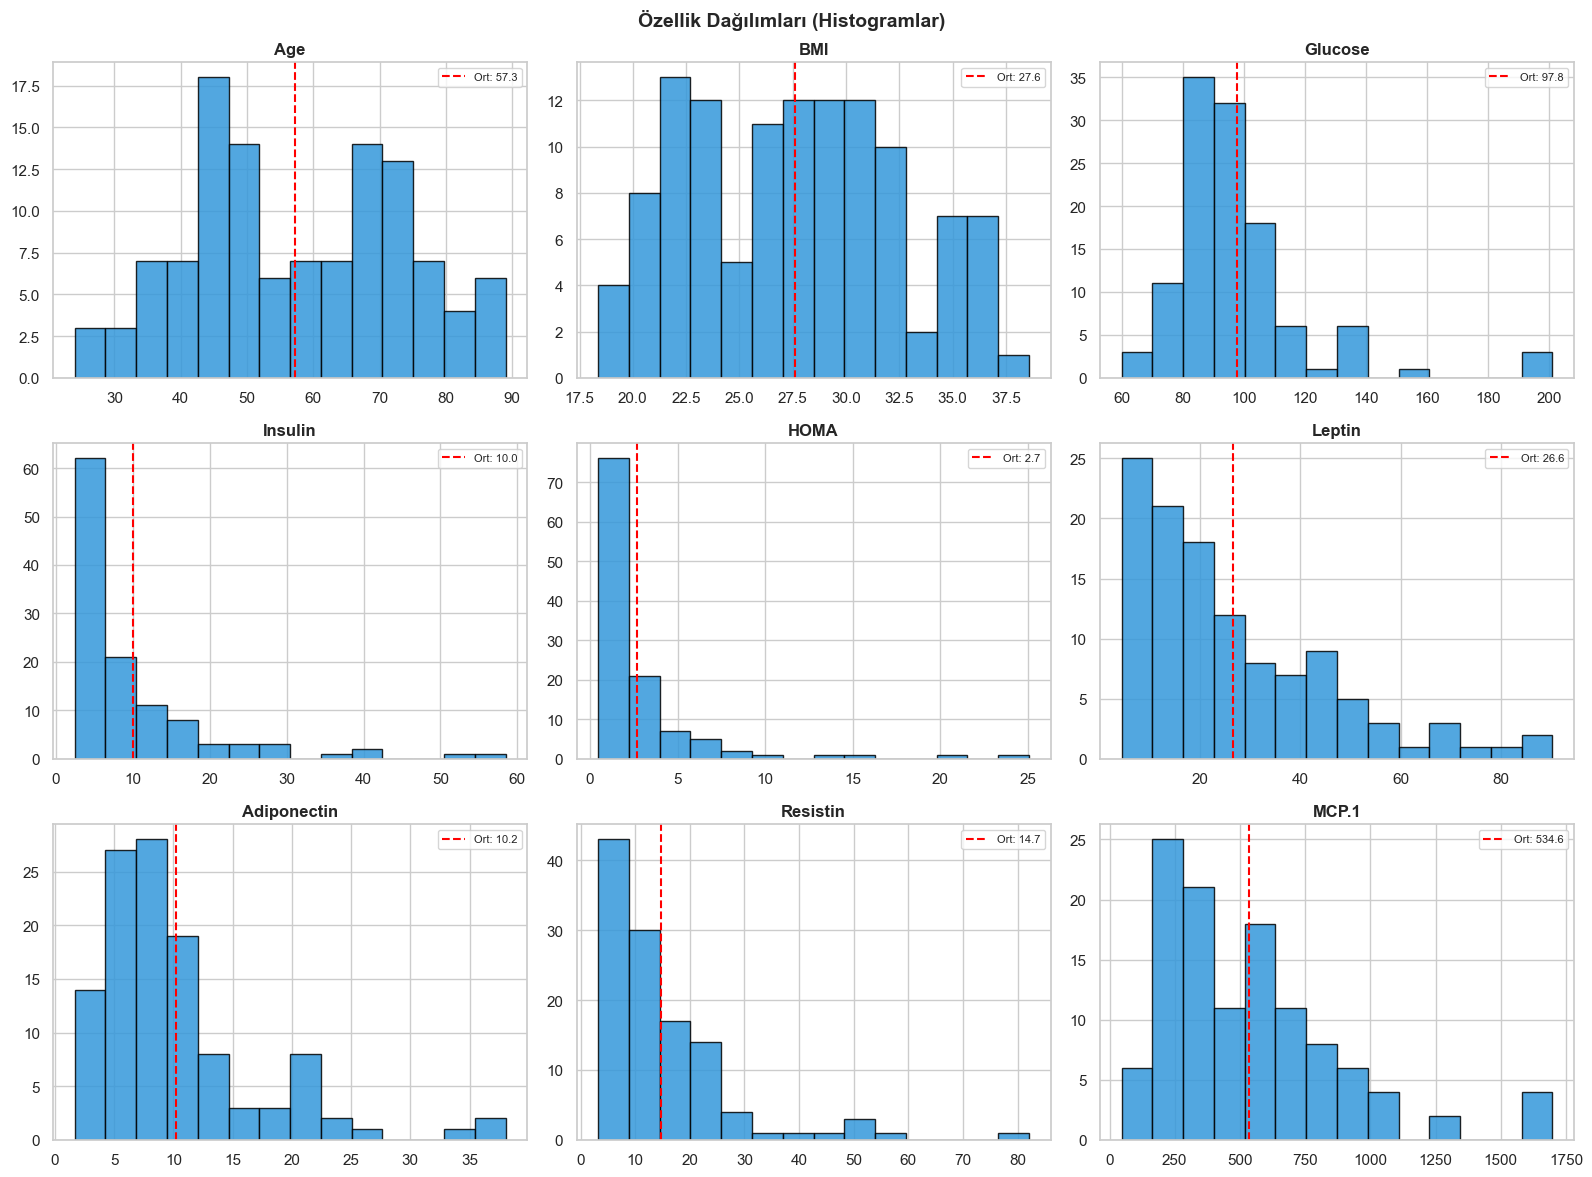

In [10]:
# Özellik histogramları
sayisal = [c for c in df.columns if c != 'Classification']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(sayisal):
    axes[i].hist(df[col], bins=14, color='#3498db', edgecolor='black', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Ort: {df[col].mean():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Özellik Dağılımları (Histogramlar)', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

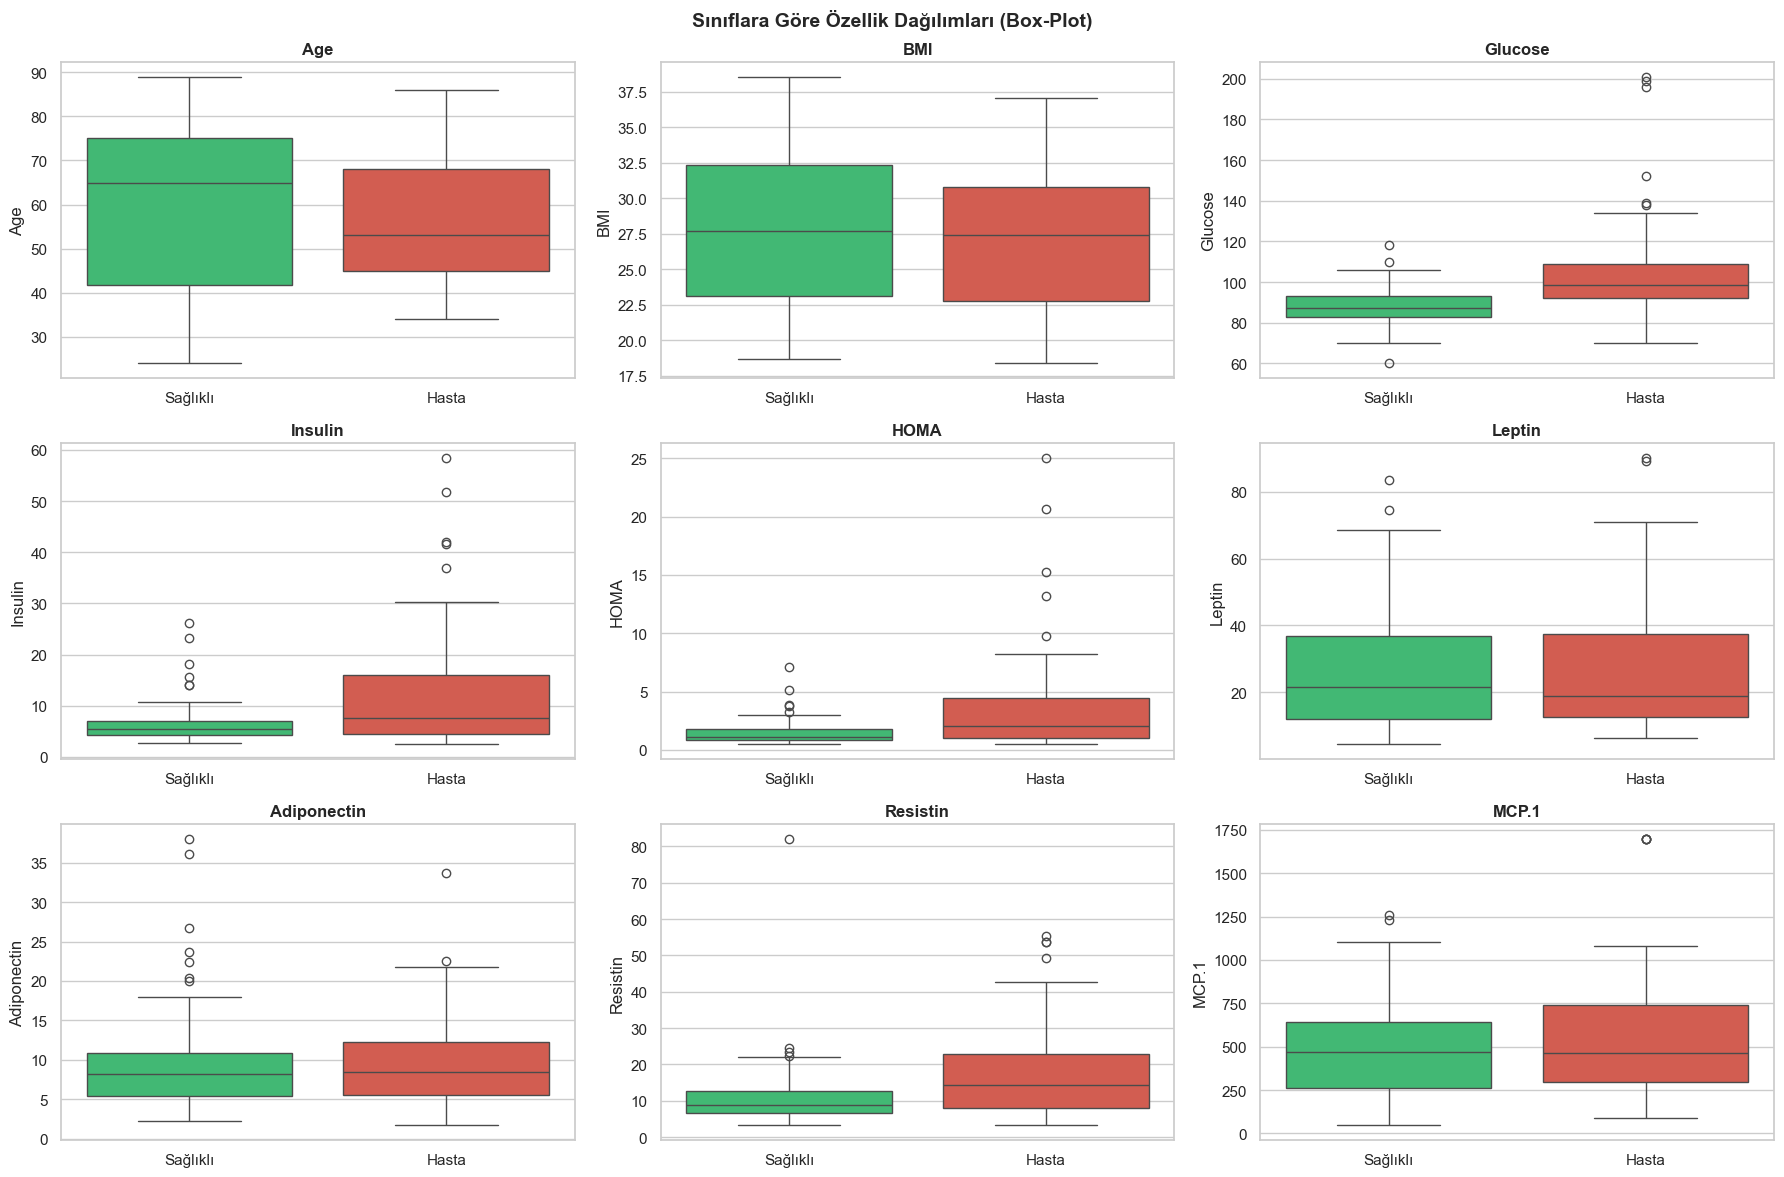

In [11]:
# Box-plot sınıfa göre
df['Sinif'] = df['Classification'].map({0:'Sağlıklı', 1:'Hasta'})
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(sayisal):
    sns.boxplot(x='Sinif', y=col, data=df,
                palette={'Sağlıklı':'#2ecc71','Hasta':'#e74c3c'}, ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Sınıflara Göre Özellik Dağılımları (Box-Plot)', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()
df.drop('Sinif', axis=1, inplace=True)

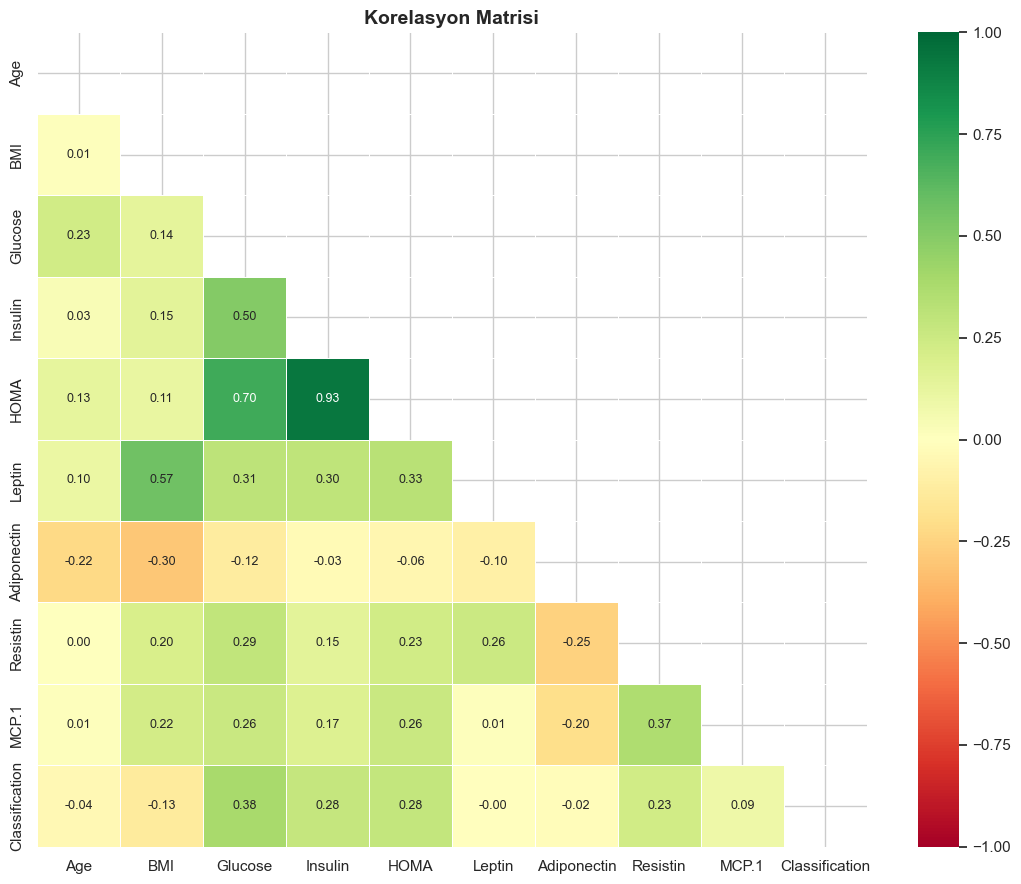

In [12]:
# Korelasyon matrisi
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Korelasyon Matrisi', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

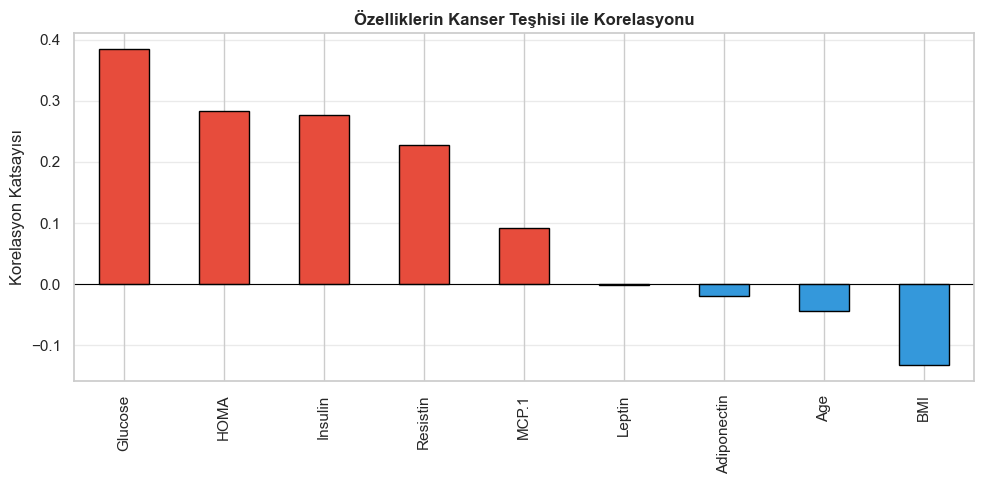

In [13]:
# Özellik-Hedef Korelasyonu
correlations = df.corr()['Classification'].sort_values(ascending=False).drop('Classification')
renkler_kor = ['#e74c3c' if v > 0 else '#3498db' for v in correlations]
plt.figure(figsize=(10, 5))
correlations.plot(kind='bar', color=renkler_kor, edgecolor='black')
plt.title('Özelliklerin Kanser Teşhisi ile Korelasyonu', fontweight='bold')
plt.ylabel('Korelasyon Katsayısı')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

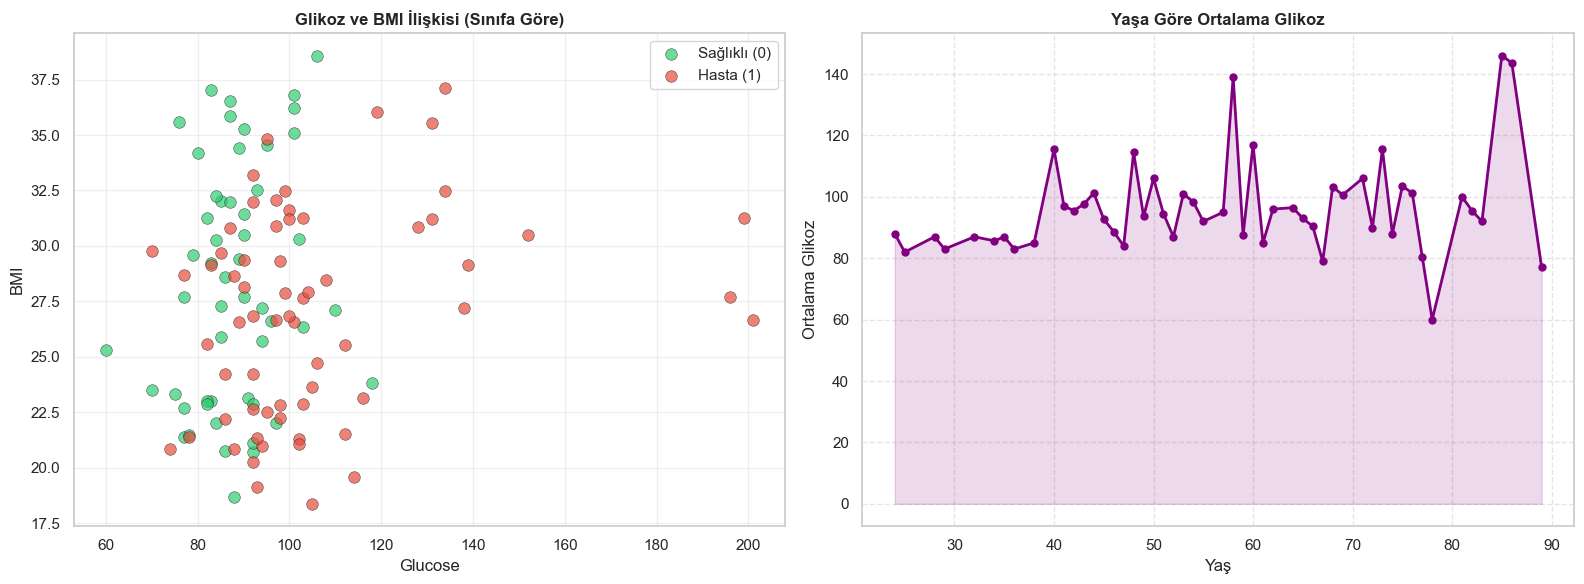

In [14]:
# Scatter: Glikoz vs BMI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
renkmap = {0:'#2ecc71', 1:'#e74c3c'}
for sinif, renk in renkmap.items():
    alt = df[df['Classification']==sinif]
    lbl = 'Sağlıklı (0)' if sinif==0 else 'Hasta (1)'
    axes[0].scatter(alt['Glucose'], alt['BMI'], c=renk, alpha=0.7,
                    label=lbl, s=70, edgecolors='k', linewidths=0.4)
axes[0].set_xlabel('Glucose'); axes[0].set_ylabel('BMI')
axes[0].set_title('Glikoz ve BMI İlişkisi (Sınıfa Göre)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

yas_glikoz = df.groupby('Age')['Glucose'].mean().reset_index()
axes[1].plot(yas_glikoz['Age'], yas_glikoz['Glucose'],
             marker='o', color='purple', linewidth=2, markersize=5)
axes[1].fill_between(yas_glikoz['Age'], yas_glikoz['Glucose'], alpha=0.15, color='purple')
axes[1].set_title('Yaşa Göre Ortalama Glikoz', fontweight='bold')
axes[1].set_xlabel('Yaş'); axes[1].set_ylabel('Ortalama Glikoz')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [15]:
# Çarpıklık & Basıklık
print("ÇARPIKLIK (Skewness):")
print(df[sayisal].skew().round(3).to_string())
print("\nBASIKLIK (Kurtosis):")
print(df[sayisal].kurtosis().round(3).to_string())

ÇARPIKLIK (Skewness):
Age            0.018
BMI            0.170
Glucose        2.593
Insulin        2.578
HOMA           3.812
Leptin         1.310
Adiponectin    1.818
Resistin       2.577
MCP.1          1.424

BASIKLIK (Kurtosis):
Age            -0.983
BMI            -0.923
Glucose         8.988
Insulin         7.502
HOMA           17.591
Leptin          1.434
Adiponectin     3.929
Resistin        8.909
MCP.1           2.582


PC1 açıklanan varyans : 0.34
PC2 açıklanan varyans : 0.17
Toplam açıklanan varyans: 0.51


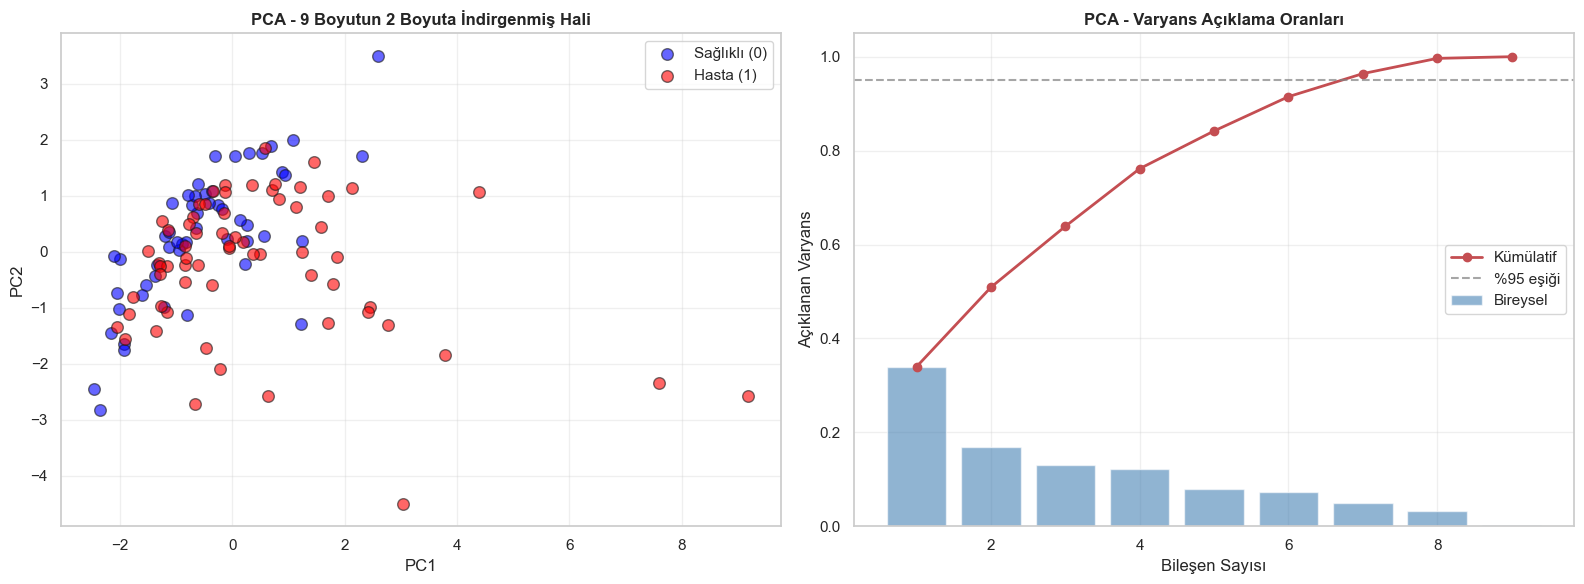

In [16]:
# BÖLÜM 4: PCA GÖRSELLEŞTİRME (sadece görsel amaçlı)

X_all = df.drop('Classification', axis=1)
y_all = df['Classification']

X_scaled_pca = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

print(f"PC1 açıklanan varyans : {pca.explained_variance_ratio_[0]:.2f}")
print(f"PC2 açıklanan varyans : {pca.explained_variance_ratio_[1]:.2f}")
print(f"Toplam açıklanan varyans: {pca.explained_variance_ratio_.sum():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_pca[y_all==0,0], X_pca[y_all==0,1], c='blue',
                label='Sağlıklı (0)', alpha=0.6, edgecolors='k', s=70)
axes[0].scatter(X_pca[y_all==1,0], X_pca[y_all==1,1], c='red',
                label='Hasta (1)', alpha=0.6, edgecolors='k', s=70)
axes[0].set_title('PCA - 9 Boyutun 2 Boyuta İndirgenmiş Hali', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

pca_full = PCA().fit(X_scaled_pca)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].bar(range(1,10), pca_full.explained_variance_ratio_,
            alpha=0.6, color='steelblue', label='Bireysel')
axes[1].plot(range(1,10), cumvar, 'ro-', linewidth=2, label='Kümülatif')
axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.7, label='%95 eşiği')
axes[1].set_title('PCA - Varyans Açıklama Oranları', fontweight='bold')
axes[1].set_xlabel('Bileşen Sayısı'); axes[1].set_ylabel('Açıklanan Varyans')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# BÖLÜM 5: OPTİMİZE EDİLMİŞ FEATURE ENGINEERING

print("YENİ ÖZELLİKLER OLUŞTURULUYOR (Optimize Edilmiş)...")
print("="*55)

df_fe = df.copy()

# 1. HOMA_IR_Index — standart klinik formül
df_fe['HOMA_IR_Index'] = (df_fe['Glucose'] * df_fe['Insulin']) / 405.0
print("1. HOMA_IR_Index        : (Glucose × Insulin) / 405")

# 2. Leptin/Adiponectin oranı — kanser riskiyle en güçlü ilişkili oran
df_fe['LA_Ratio'] = df_fe['Leptin'] / (df_fe['Adiponectin'] + 1e-6)
print("2. LA_Ratio             : Leptin / Adiponectin")

# 3. Glucose_BMI_Ratio — metabolik sendrom göstergesi
df_fe['Glucose_BMI_Ratio'] = df_fe['Glucose'] / (df_fe['BMI'] + 1e-6)
print("3. Glucose_BMI_Ratio    : Glucose / BMI")

# 4. Metabolic_Risk — birden fazla faktörün normalize bileşimi
df_fe['Metabolic_Risk'] = (
    (df_fe['Glucose']  / df_fe['Glucose'].mean()) +
    (df_fe['BMI']      / df_fe['BMI'].mean())     +
    (df_fe['Resistin'] / df_fe['Resistin'].mean())
) / 3.0
print("4. Metabolic_Risk       : (norm_Glucose + norm_BMI + norm_Resistin) / 3")

# 5. Age_BMI etkileşimi — yaşla birlikte artan obezite riski
df_fe['Age_BMI'] = df_fe['Age'] * df_fe['BMI']
print("5. Age_BMI              : Age × BMI")

# 6. Insulin_Sensitivity — HOMA'nın tersi
df_fe['Insulin_Sensitivity'] = 1.0 / (df_fe['HOMA'] + 1e-6)
print("6. Insulin_Sensitivity  : 1 / HOMA")

# 7. Resistin/Leptin oranı — inflamasyon/adipokin dengesi
df_fe['Resistin_Leptin_Ratio'] = df_fe['Resistin'] / (df_fe['Leptin'] + 1e-6)
print("7. Resistin_Leptin_Ratio: Resistin / Leptin")

# 8. Log dönüşümleri — çarpık dağılımları düzeltir
# NOT: Log alınan sütunların orijinalleri çıkarılıyor (multicollinearity önlemi)
log_cols = ['Insulin', 'HOMA', 'MCP.1', 'Resistin', 'Leptin']
for col in log_cols:
    df_fe[f'Log_{col}'] = np.log1p(df_fe[col])
    print(f"8. Log_{col:<20}: log(1 + {col})")
df_fe.drop(columns=log_cols, inplace=True)
print(f"\nNOT: Log dönüşümü yapılan orijinal sütunlar çıkarıldı (multicollinearity önlemi).")
print(f"Toplam özellik sayısı: {df_fe.shape[1]-1} (orijinal 4 + türetilmiş {df_fe.shape[1]-5})")

YENİ ÖZELLİKLER OLUŞTURULUYOR (Optimize Edilmiş)...
1. HOMA_IR_Index        : (Glucose × Insulin) / 405
2. LA_Ratio             : Leptin / Adiponectin
3. Glucose_BMI_Ratio    : Glucose / BMI
4. Metabolic_Risk       : (norm_Glucose + norm_BMI + norm_Resistin) / 3
5. Age_BMI              : Age × BMI
6. Insulin_Sensitivity  : 1 / HOMA
7. Resistin_Leptin_Ratio: Resistin / Leptin
8. Log_Insulin             : log(1 + Insulin)
8. Log_HOMA                : log(1 + HOMA)
8. Log_MCP.1               : log(1 + MCP.1)
8. Log_Resistin            : log(1 + Resistin)
8. Log_Leptin              : log(1 + Leptin)

NOT: Log dönüşümü yapılan orijinal sütunlar çıkarıldı (multicollinearity önlemi).
Toplam özellik sayısı: 16 (orijinal 4 + türetilmiş 12)


Yeni Özelliklerin Hedef ile Korelasyonu:
Glucose_BMI_Ratio        0.3981
Log_HOMA                 0.3245
HOMA_IR_Index            0.2840
Log_Resistin             0.2749
Log_Insulin              0.2610
Metabolic_Risk           0.2584
Resistin_Leptin_Ratio    0.2422
Log_MCP.1                0.0785
Log_Leptin               0.0198
LA_Ratio                -0.0161
Age_BMI                 -0.0796
Insulin_Sensitivity     -0.2365


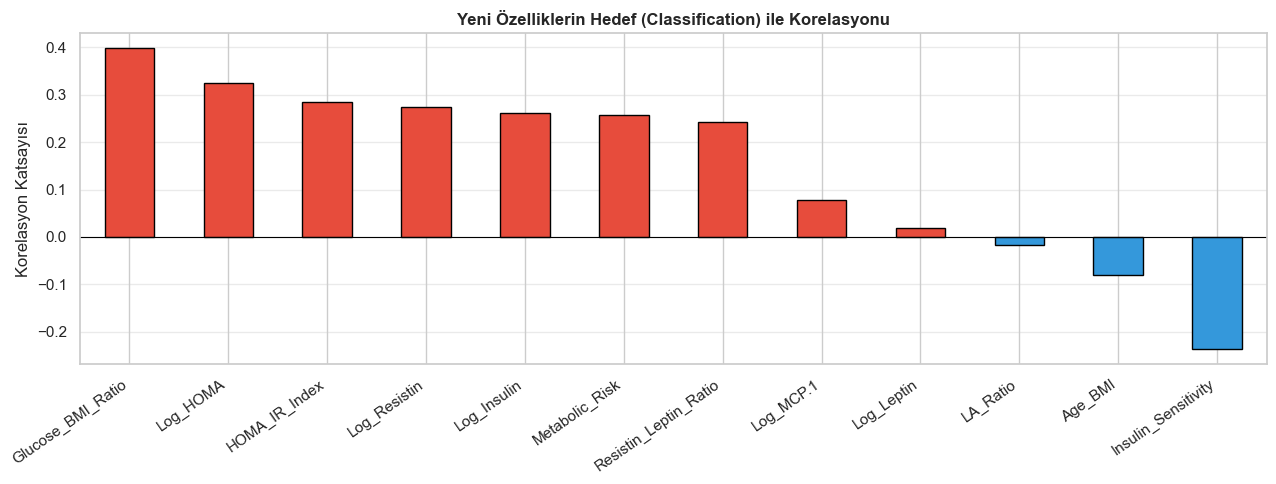

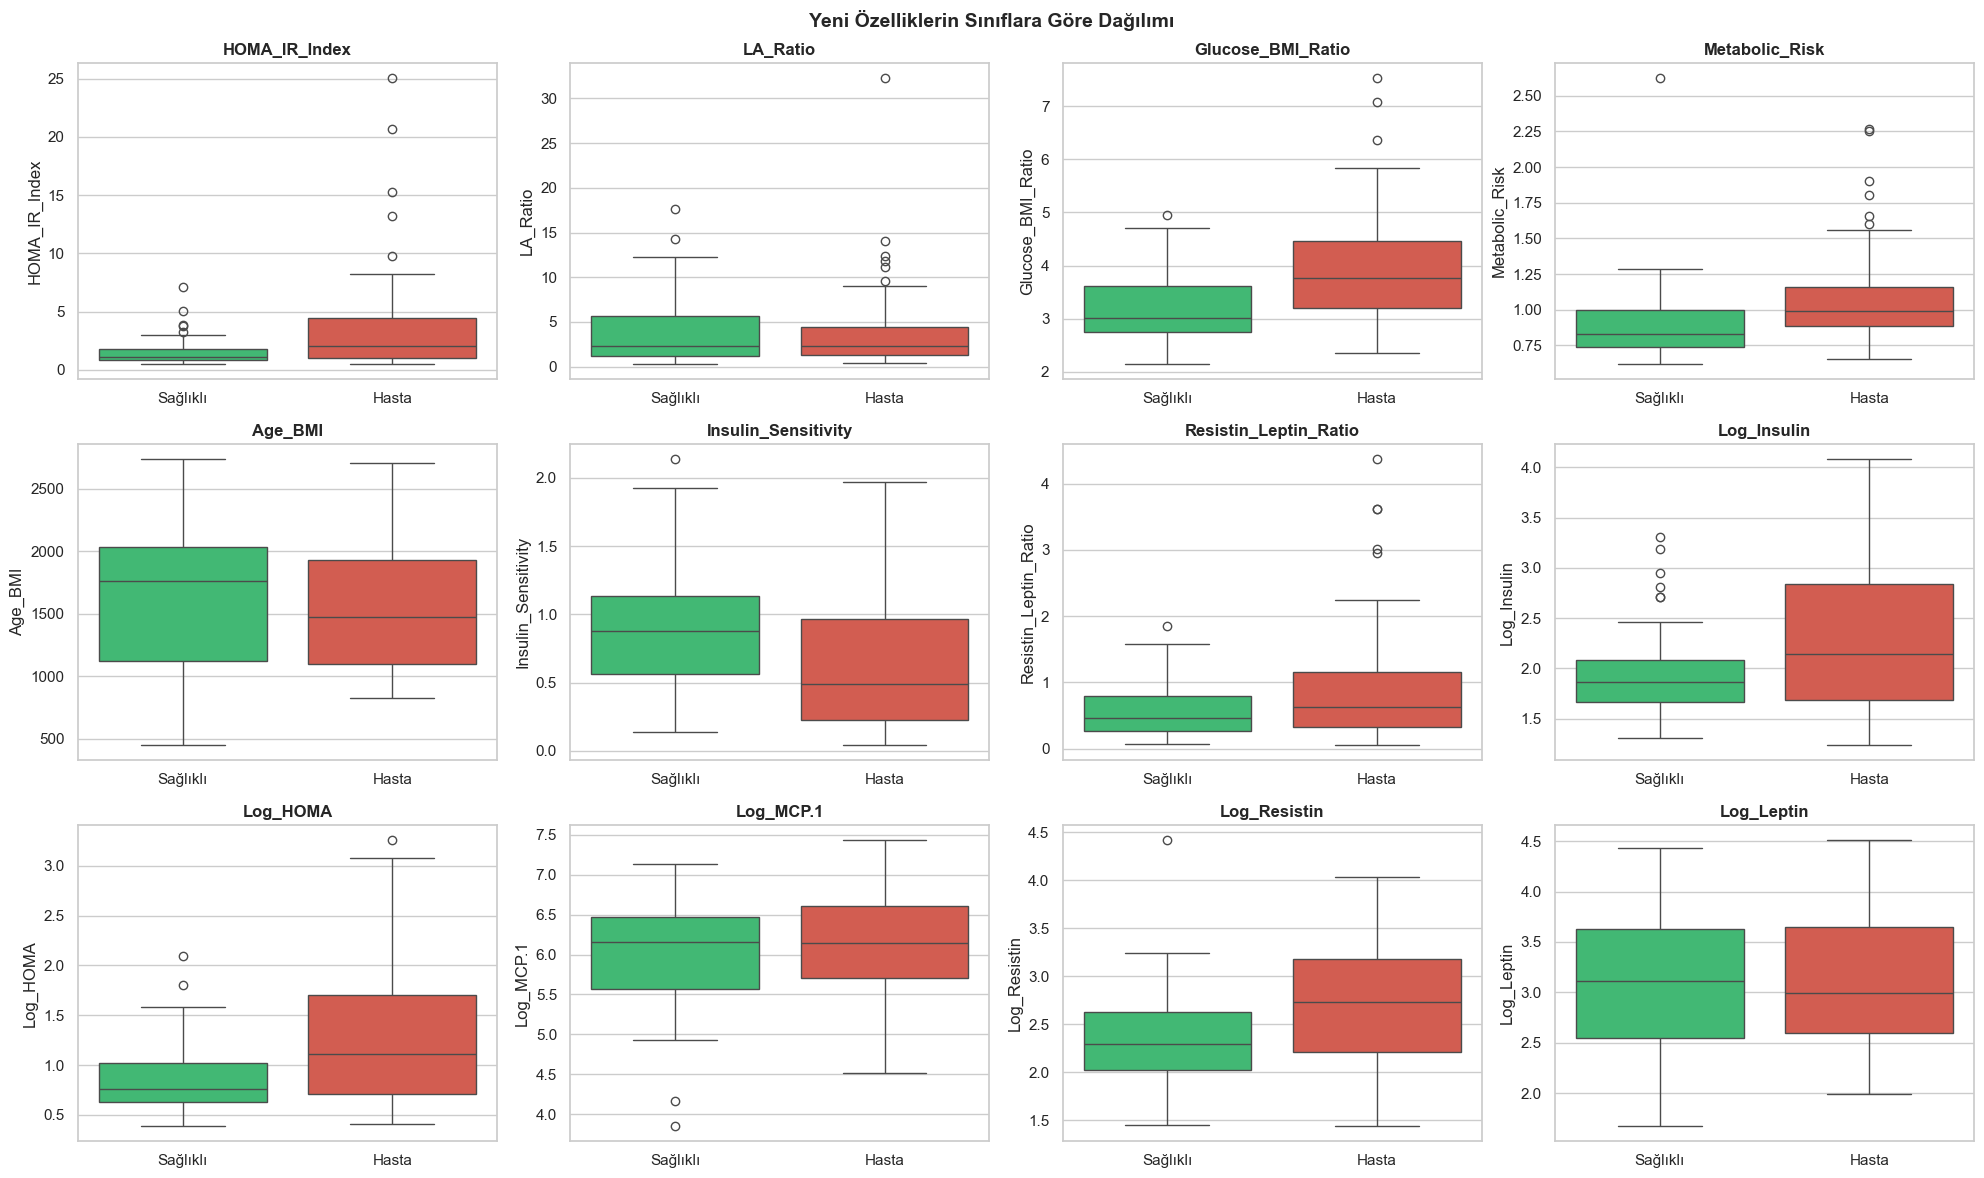

In [18]:
# Yeni özelliklerin hedef ile korelasyonu
yeni_ozellikler = ['HOMA_IR_Index','LA_Ratio','Glucose_BMI_Ratio',
                   'Metabolic_Risk','Age_BMI','Insulin_Sensitivity',
                   'Resistin_Leptin_Ratio',
                   'Log_Insulin','Log_HOMA','Log_MCP.1','Log_Resistin','Log_Leptin']

mevcut_yeni = [c for c in yeni_ozellikler if c in df_fe.columns]
kor_yeni = df_fe[mevcut_yeni + ['Classification']].corr()['Classification'].drop('Classification').sort_values(ascending=False)
print("Yeni Özelliklerin Hedef ile Korelasyonu:")
print(kor_yeni.round(4).to_string())

plt.figure(figsize=(13, 5))
renkler_yeni = ['#e74c3c' if v > 0 else '#3498db' for v in kor_yeni]
kor_yeni.plot(kind='bar', color=renkler_yeni, edgecolor='black')
plt.title('Yeni Özelliklerin Hedef (Classification) ile Korelasyonu', fontweight='bold')
plt.ylabel('Korelasyon Katsayısı')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.4)
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

# Yeni özelliklerin boxplot görselleştirmesi
df_fe['Sinif'] = df_fe['Classification'].map({0:'Sağlıklı',1:'Hasta'})
n_cols = len(mevcut_yeni)
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(mevcut_yeni):
    sns.boxplot(x='Sinif', y=col, data=df_fe,
                palette={'Sağlıklı':'#2ecc71','Hasta':'#e74c3c'}, ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Yeni Özelliklerin Sınıflara Göre Dağılımı', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()
df_fe.drop('Sinif', axis=1, inplace=True)

In [19]:
# BÖLÜM 6: VERİ HAZIRLAMA — DOĞRU PIPELINE

X_raw_all = df_fe.drop('Classification', axis=1)
y_raw_all  = df_fe['Classification']

# 1. Outlier temizleme (z-score > 3.5)
z_scores   = np.abs(stats.zscore(X_raw_all))
mask_clean = (z_scores < 3.5).all(axis=1)
X_clean    = X_raw_all[mask_clean].copy()
y_clean    = y_raw_all[mask_clean].copy()
print(f"Outlier sonrası: {len(X_raw_all)} → {len(X_clean)} örnek")
print(f"Sınıf dağılımı:\n{y_clean.value_counts().to_string()}")

Outlier sonrası: 116 → 106 örnek
Sınıf dağılımı:
Classification
1    57
0    49


In [20]:
# 2. Train/Test bölünmesi (%80/%20, stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)
print(f"Eğitim seti : {X_train_raw.shape[0]} örnek")
print(f"Test seti   : {X_test_raw.shape[0]} örnek")
print(f"\nEğitim sınıf dağılımı:\n{y_train.value_counts().to_string()}")
print(f"\nTest sınıf dağılımı:\n{y_test.value_counts().to_string()}")

Eğitim seti : 84 örnek
Test seti   : 22 örnek

Eğitim sınıf dağılımı:
Classification
1    45
0    39

Test sınıf dağılımı:
Classification
1    12
0    10


In [21]:
# 3. RobustScaler — outlier'lara dayanıklı ölçeklendirme
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_raw)   # sadece train'e fit
X_test_sc  = scaler.transform(X_test_raw)        # test'e sadece transform
print(f"RobustScaler uygulandı.")
print(f"X_train_sc: {X_train_sc.shape}  |  X_test_sc: {X_test_sc.shape}")

RobustScaler uygulandı.
X_train_sc: (84, 16)  |  X_test_sc: (22, 16)


Seçilen 10 özellik: ['BMI', 'Glucose', 'HOMA_IR_Index', 'LA_Ratio', 'Glucose_BMI_Ratio', 'Metabolic_Risk', 'Insulin_Sensitivity', 'Log_Insulin', 'Log_HOMA', 'Log_Resistin']

F-Skoru Tablosu:


,Özellik,F-Skoru,p-Değeri,Seçildi
0,Glucose,23.623,0.00001,True
1,Glucose_BMI_Ratio,20.786,0.00002,True
2,Log_HOMA,10.322,0.00188,True
3,HOMA_IR_Index,8.561,0.00444,True
4,Metabolic_Risk,6.720,0.01129,True
5,Log_Insulin,6.476,0.01281,True
6,Insulin_Sensitivity,6.467,0.01287,True
7,Log_Resistin,3.898,0.05171,True
8,BMI,2.734,0.10208,True
9,LA_Ratio,2.693,0.10465,True


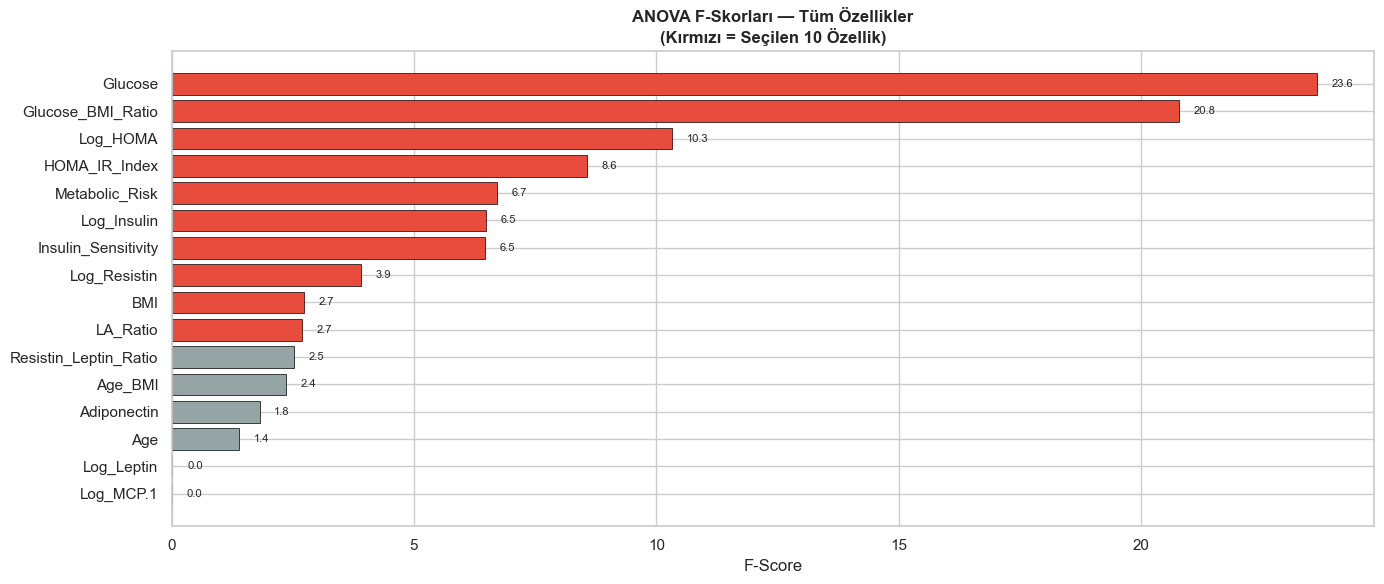


X_train_fs: (84, 10)  |  X_test_fs: (22, 10)


In [22]:
# 4. SelectKBest — SMOTE'dan ÖNCE, sadece gerçek train verisiyle fit edilir
selector   = SelectKBest(score_func=f_classif, k=10)
X_train_fs = selector.fit_transform(X_train_sc, y_train)   # gerçek train
X_test_fs  = selector.transform(X_test_sc)                 # test

secilen_mask       = selector.get_support()
secilen_ozellikler = X_clean.columns[secilen_mask]

fs_df = pd.DataFrame({
    'Özellik' : X_clean.columns,
    'F-Skoru' : selector.scores_.round(3),
    'p-Değeri': selector.pvalues_.round(5),
    'Seçildi' : secilen_mask
}).sort_values('F-Skoru', ascending=False)

print(f"Seçilen {X_train_fs.shape[1]} özellik: {list(secilen_ozellikler)}")
print(f"\nF-Skoru Tablosu:")
display(fs_df.reset_index(drop=True))

# F-Skoru görselleştirmesi
plt.figure(figsize=(14, 6))
bars = plt.barh(
    fs_df['Özellik'], fs_df['F-Skoru'],
    color=['#e74c3c' if bool(s) else '#95a5a6' for s in fs_df['Seçildi']],
    edgecolor='black', linewidth=0.5
)
plt.gca().invert_yaxis()
plt.title('ANOVA F-Skorları — Tüm Özellikler\n(Kırmızı = Seçilen 10 Özellik)', fontweight='bold')
plt.xlabel('F-Score')
for bar, val in zip(bars, fs_df['F-Skoru']):
    plt.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nX_train_fs: {X_train_fs.shape}  |  X_test_fs: {X_test_fs.shape}")

In [23]:
# 5. SMOTE — SelectKBest'ten SONRA, seçilmiş özellikler üzerinde
# k_neighbors=4: küçük veri seti için daha güvenli
smote = SMOTE(random_state=42, k_neighbors=4)
X_train_res, y_train_sm = smote.fit_resample(X_train_fs, y_train)
print(f"SMOTE öncesi eğitim  : {len(X_train_fs)} örnek")
print(f"SMOTE sonrası eğitim : {len(X_train_res)} örnek")
print(f"Yeni sınıf dağılımı  : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")
print(f"\nFinal pipeline: Scale → SelectKBest (k=10, gerçek train) → SMOTE")
print(f"X_train_res: {X_train_res.shape}  |  X_test_fs: {X_test_fs.shape}")

SMOTE öncesi eğitim  : 84 örnek
SMOTE sonrası eğitim : 90 örnek
Yeni sınıf dağılımı  : {np.int64(0): np.int64(45), np.int64(1): np.int64(45)}

Final pipeline: Scale → SelectKBest (k=10, gerçek train) → SMOTE
X_train_res: (90, 10)  |  X_test_fs: (22, 10)


In [24]:
# BÖLÜM 7: LOJİSTİK REGRESYON
print("Lojistik Regresyon eğitimi başlıyor...")

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid_lr = {
    'C'           : [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_lr, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train_res, y_train_sm)

best_lr   = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_fs)

print(f"En iyi parametreler : {grid_lr.best_params_}")
print(f"CV Accuracy (10-fold): {grid_lr.best_score_:.4f}")
print(f"\n--- Lojistik Regresyon Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_lr, target_names=['Sağlıklı (0)', 'Hasta (1)']))

Lojistik Regresyon eğitimi başlıyor...
En iyi parametreler : {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
CV Accuracy (10-fold): 0.7444

--- Lojistik Regresyon Sınıflandırma Raporu ---
              precision    recall  f1-score   support

Sağlıklı (0)       0.88      0.70      0.78        10
   Hasta (1)       0.79      0.92      0.85        12

    accuracy                           0.82        22
   macro avg       0.83      0.81      0.81        22
weighted avg       0.83      0.82      0.82        22



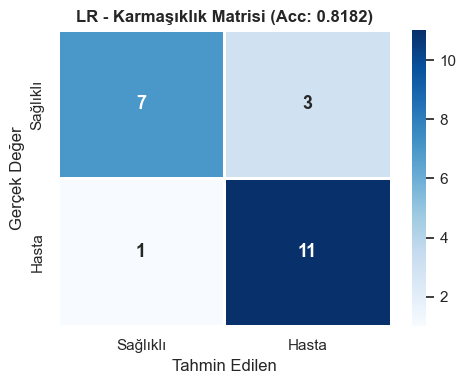

In [25]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sağlıklı','Hasta'], yticklabels=['Sağlıklı','Hasta'],
            linewidths=1, linecolor='white', annot_kws={'size':13,'weight':'bold'})
acc = accuracy_score(y_test, y_pred_lr)
plt.title(f"LR - Karmaşıklık Matrisi (Acc: {acc:.4f})", fontweight='bold')
plt.xlabel('Tahmin Edilen'); plt.ylabel('Gerçek Değer')
plt.tight_layout(); plt.show()

,Özellik,Katsayı
0,BMI,-1.367485
2,HOMA_IR_Index,-0.474561
3,LA_Ratio,-0.231249
9,Log_Resistin,0.146808
4,Glucose_BMI_Ratio,0.519300
8,Log_HOMA,0.855480
6,Insulin_Sensitivity,1.067834
1,Glucose,1.235260
7,Log_Insulin,1.316185
5,Metabolic_Risk,1.548933


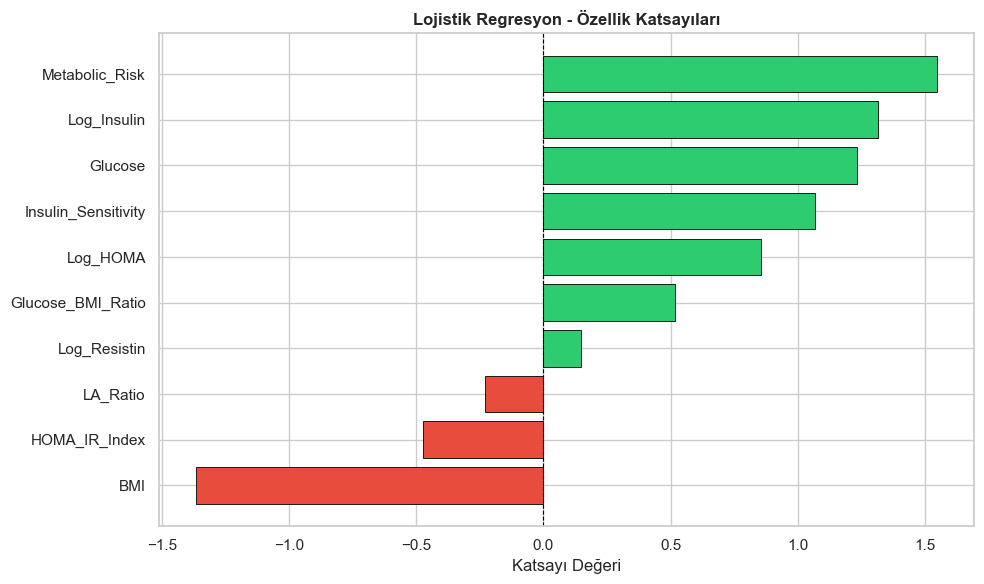

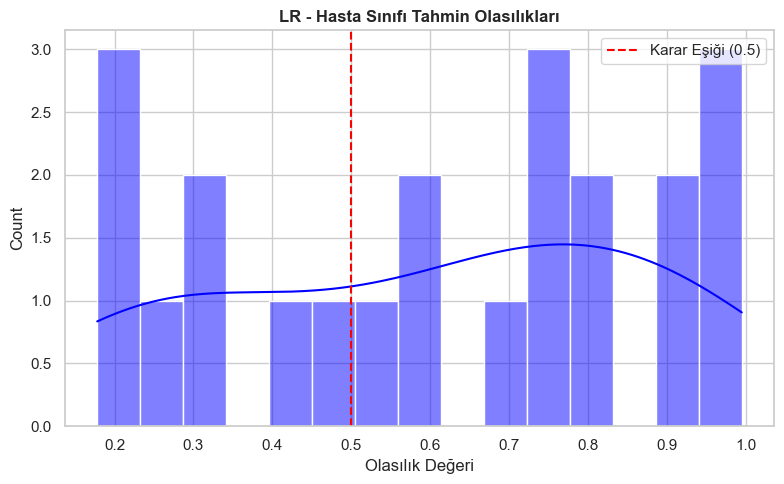

In [26]:
# LR Özellik Katsayıları
feature_importance_lr = pd.DataFrame({
    'Özellik': secilen_ozellikler,
    'Katsayı': best_lr.coef_[0]
}).sort_values('Katsayı', ascending=True)

display(feature_importance_lr)
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in feature_importance_lr['Katsayı']]
plt.barh(feature_importance_lr['Özellik'], feature_importance_lr['Katsayı'],
         color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Lojistik Regresyon - Özellik Katsayıları', fontweight='bold')
plt.xlabel('Katsayı Değeri')
plt.tight_layout(); plt.show()

# Tahmin olasılıkları
probs_lr = best_lr.predict_proba(X_test_fs)[:, 1]
plt.figure(figsize=(8, 5))
sns.histplot(probs_lr, kde=True, color='blue', bins=15)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Karar Eşiği (0.5)')
plt.title('LR - Hasta Sınıfı Tahmin Olasılıkları', fontweight='bold')
plt.xlabel('Olasılık Değeri'); plt.legend()
plt.tight_layout(); plt.show()

In [27]:
# BÖLÜM 8: SVM (DESTEK VEKTÖR MAKİNESİ)
print("SVM eğitimi başlıyor...")

param_grid_svm = {
    'C'           : [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    'gamma'       : ['scale', 'auto', 1.0, 0.5, 0.1, 0.01, 0.001, 0.0001],
    'kernel'      : ['rbf', 'linear', 'poly', 'sigmoid'],
    'degree'      : [2, 3],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)
grid_svm.fit(X_train_res, y_train_sm)

best_svm   = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_fs)

print(f"En iyi parametreler : {grid_svm.best_params_}")
print(f"CV Accuracy (10-fold): {grid_svm.best_score_:.4f}")
print(f"\n--- SVM Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_svm, target_names=['Sağlıklı (0)', 'Hasta (1)']))

SVM eğitimi başlıyor...
En iyi parametreler : {'C': 0.1, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
CV Accuracy (10-fold): 0.7778

--- SVM Sınıflandırma Raporu ---
              precision    recall  f1-score   support

Sağlıklı (0)       0.78      0.70      0.74        10
   Hasta (1)       0.77      0.83      0.80        12

    accuracy                           0.77        22
   macro avg       0.77      0.77      0.77        22
weighted avg       0.77      0.77      0.77        22



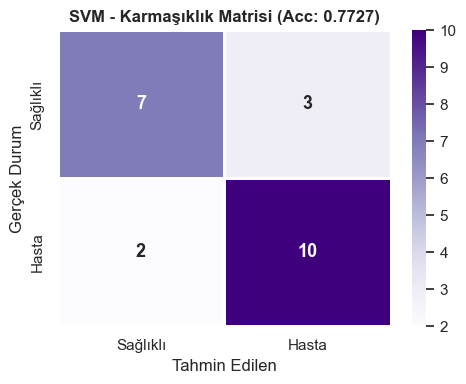

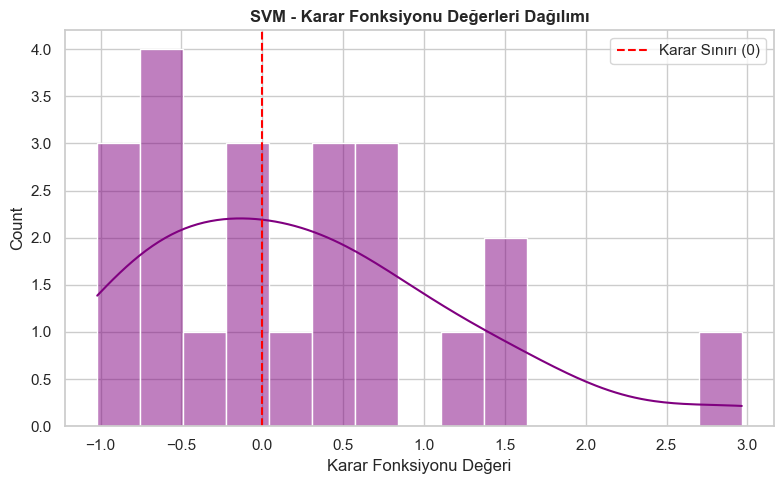

In [28]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sağlıklı','Hasta'], yticklabels=['Sağlıklı','Hasta'],
            linewidths=1, linecolor='white', annot_kws={'size':13,'weight':'bold'})
acc = accuracy_score(y_test, y_pred_svm)
plt.title(f"SVM - Karmaşıklık Matrisi (Acc: {acc:.4f})", fontweight='bold')
plt.xlabel('Tahmin Edilen'); plt.ylabel('Gerçek Durum')
plt.tight_layout(); plt.show()

# Karar fonksiyonu dağılımı
svm_dec = best_svm.decision_function(X_test_fs)
plt.figure(figsize=(8, 5))
sns.histplot(svm_dec, kde=True, color='purple', bins=15)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Karar Sınırı (0)')
plt.title('SVM - Karar Fonksiyonu Değerleri Dağılımı', fontweight='bold')
plt.xlabel('Karar Fonksiyonu Değeri'); plt.legend()
plt.tight_layout(); plt.show()

In [29]:
# BÖLÜM 9: ANN (YAPAY SİNİR AĞLARI - MLP)
print("ANN eğitimi başlıyor...")
print("NOT: lbfgs solver küçük veri setlerinde adam'dan daha iyi çalışır.")
print("     early_stopping sadece adam/sgd ile çalışır; lbfgs için max_iter yeterli.")

# adam için (early_stopping destekler)
param_grid_ann_adam = {
    'hidden_layer_sizes': [(32,16),(64,32),(128,64),(64,32,16),(128,64,32)],
    'activation'        : ['relu','tanh','logistic'],
    'alpha'             : [0.0001,0.001,0.01,0.05,0.1],
    'learning_rate_init': [0.0005,0.001,0.005,0.01],
    'solver'            : ['adam'],
    'batch_size'        : ['auto',16,32]
}
grid_adam = GridSearchCV(
    MLPClassifier(max_iter=5000, random_state=42,
                  early_stopping=True, n_iter_no_change=30,
                  validation_fraction=0.1),
    param_grid_ann_adam, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)
grid_adam.fit(X_train_res, y_train_sm)

# lbfgs için (early_stopping YOK — küçük veri için tercih edilir)
param_grid_ann_lbfgs = {
    'hidden_layer_sizes': [(32,),(64,),(32,16),(64,32),(100,50)],
    'activation'        : ['relu','tanh','logistic'],
    'alpha'             : [0.0001,0.001,0.01,0.05,0.1,0.5],
    'solver'            : ['lbfgs']
}
grid_lbfgs = GridSearchCV(
    MLPClassifier(max_iter=5000, random_state=42),
    param_grid_ann_lbfgs, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)
grid_lbfgs.fit(X_train_res, y_train_sm)

# İkisinden iyisini seç
if grid_adam.best_score_ >= grid_lbfgs.best_score_:
    best_ann = grid_adam.best_estimator_
    print(f"Seçilen solver: adam  (CV Accuracy={grid_adam.best_score_:.4f})")
else:
    best_ann = grid_lbfgs.best_estimator_
    print(f"Seçilen solver: lbfgs (CV Accuracy={grid_lbfgs.best_score_:.4f})")

y_pred_ann  = best_ann.predict(X_test_fs)
y_probs_ann = best_ann.predict_proba(X_test_fs)[:, 1]

print(f"\nEn iyi parametreler : {best_ann.get_params()}")
print(f"\n--- ANN FİNAL PERFORMANS RAPORU ---")
print(classification_report(y_test, y_pred_ann, target_names=['Sağlıklı (0)', 'Hasta (1)']))

ANN eğitimi başlıyor...
NOT: lbfgs solver küçük veri setlerinde adam'dan daha iyi çalışır.
     early_stopping sadece adam/sgd ile çalışır; lbfgs için max_iter yeterli.
Seçilen solver: adam  (CV Accuracy=0.7889)

En iyi parametreler : {'activation': 'tanh', 'alpha': 0.1, 'batch_size': 32, 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': True, 'epsilon': 1e-08, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_fun': 15000, 'max_iter': 5000, 'momentum': 0.9, 'n_iter_no_change': 30, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}

--- ANN FİNAL PERFORMANS RAPORU ---
              precision    recall  f1-score   support

Sağlıklı (0)       0.67      0.60      0.63        10
   Hasta (1)       0.69      0.75      0.72        12

    accuracy                           0.68        22
   macro avg       0.68      

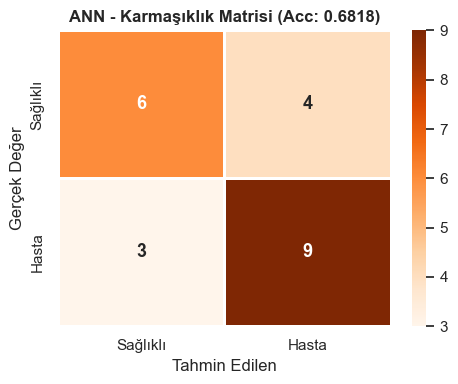

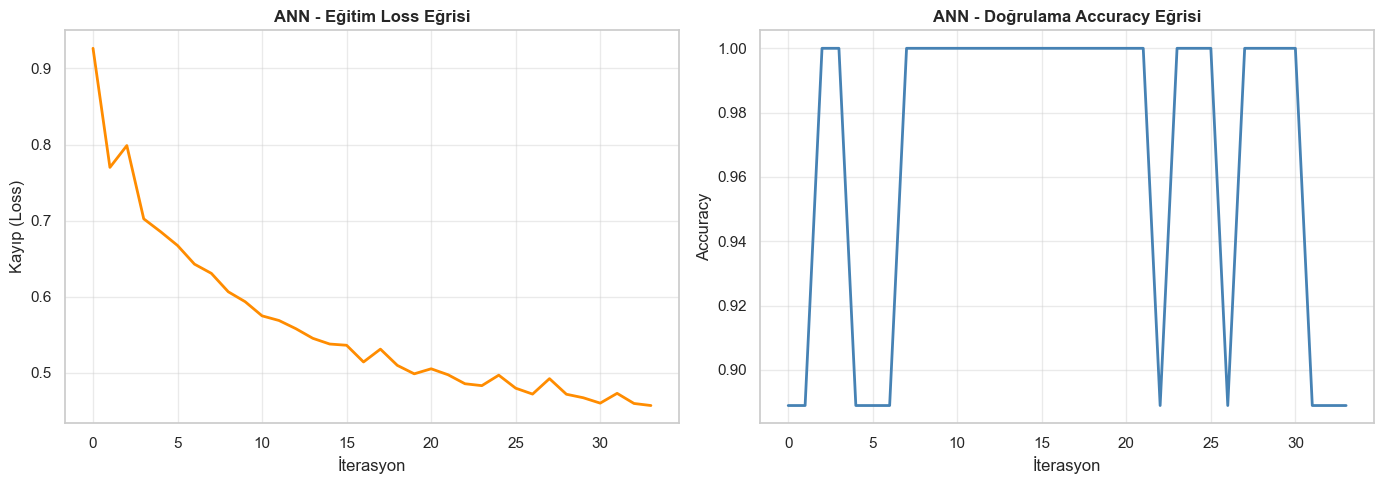

Aktivasyon : tanh
Katman     : (128, 64, 32)
Katman sayı: 5


In [30]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sağlıklı','Hasta'], yticklabels=['Sağlıklı','Hasta'],
            linewidths=1, linecolor='white', annot_kws={'size':13,'weight':'bold'})
acc = accuracy_score(y_test, y_pred_ann)
plt.title(f"ANN - Karmaşıklık Matrisi (Acc: {acc:.4f})", fontweight='bold')
plt.xlabel('Tahmin Edilen'); plt.ylabel('Gerçek Değer')
plt.tight_layout(); plt.show()

# Loss eğrisi
if hasattr(best_ann, 'loss_curve_') and best_ann.loss_curve_:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(best_ann.loss_curve_, color='darkorange', linewidth=2)
    axes[0].set_title('ANN - Eğitim Loss Eğrisi', fontweight='bold')
    axes[0].set_xlabel('İterasyon'); axes[0].set_ylabel('Kayıp (Loss)')
    axes[0].grid(True, alpha=0.4)
    if hasattr(best_ann,'validation_scores_') and best_ann.validation_scores_:
        axes[1].plot(best_ann.validation_scores_, color='steelblue', linewidth=2)
        axes[1].set_title('ANN - Doğrulama Accuracy Eğrisi', fontweight='bold')
        axes[1].set_xlabel('İterasyon'); axes[1].set_ylabel('Accuracy')
        axes[1].grid(True, alpha=0.4)
    else:
        axes[1].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("Loss curve: lbfgs solver seçildiğinde loss_curve_ üretilmez.")

print(f"Aktivasyon : {best_ann.activation}")
print(f"Katman     : {best_ann.hidden_layer_sizes}")
print(f"Katman sayı: {best_ann.n_layers_}")

Voting Ensemble oluşturuluyor (LR + SVM + ANN)...

--- Voting Ensemble Sınıflandırma Raporu ---
              precision    recall  f1-score   support

Sağlıklı (0)       0.88      0.70      0.78        10
   Hasta (1)       0.79      0.92      0.85        12

    accuracy                           0.82        22
   macro avg       0.83      0.81      0.81        22
weighted avg       0.83      0.82      0.82        22



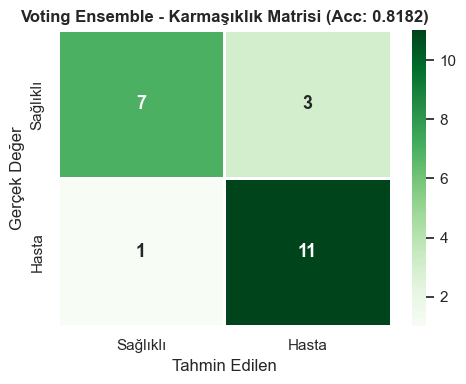

In [31]:
# BÖLÜM 10: VOTING ENSEMBLE
print("Voting Ensemble oluşturuluyor (LR + SVM + ANN)...")

voting_clf = VotingClassifier(
    estimators=[('lr', best_lr), ('svm', best_svm), ('ann', best_ann)],
    voting='soft'
)
voting_clf.fit(X_train_res, y_train_sm)
y_pred_vote  = voting_clf.predict(X_test_fs)
y_probs_vote = voting_clf.predict_proba(X_test_fs)[:, 1]

print(f"\n--- Voting Ensemble Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_vote, target_names=['Sağlıklı (0)', 'Hasta (1)']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_vote), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sağlıklı','Hasta'], yticklabels=['Sağlıklı','Hasta'],
            linewidths=1, linecolor='white', annot_kws={'size':13,'weight':'bold'})
acc = accuracy_score(y_test, y_pred_vote)
plt.title(f"Voting Ensemble - Karmaşıklık Matrisi (Acc: {acc:.4f})", fontweight='bold')
plt.xlabel('Tahmin Edilen'); plt.ylabel('Gerçek Değer')
plt.tight_layout(); plt.show()

In [32]:
# BÖLÜM 10b: EŞİK OPTİMİZASYONU (Threshold Tuning)
print("=" * 55)
print("EŞİK OPTİMİZASYONU (Accuracy odaklı)")
print("=" * 55)

def find_best_threshold(model, X_te, y_te, name="Model"):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.20, 0.81, 0.05)
    results = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        results.append({
            'Threshold' : round(t, 2),
            'Accuracy'  : round(accuracy_score(y_te, preds), 4),
            'Precision' : round(precision_score(y_te, preds, zero_division=0), 4),
            'Recall'    : round(recall_score(y_te, preds), 4),
            'F1'        : round(f1_score(y_te, preds), 4)
        })
    df_thr = pd.DataFrame(results)
    best_row = df_thr.loc[df_thr['Accuracy'].idxmax()]
    print(f"\n{name} — En iyi Accuracy threshold: {best_row['Threshold']}")
    display(df_thr)
    return float(best_row['Threshold'])

best_thr_lr  = find_best_threshold(best_lr,  X_test_fs, y_test, "LR")
best_thr_svm = find_best_threshold(best_svm, X_test_fs, y_test, "SVM")
best_thr_ann = find_best_threshold(best_ann, X_test_fs, y_test, "ANN")

# Optimal threshold ile tahminler
y_pred_lr_opt  = (best_lr.predict_proba(X_test_fs)[:,1]  >= best_thr_lr).astype(int)
y_pred_svm_opt = (best_svm.predict_proba(X_test_fs)[:,1] >= best_thr_svm).astype(int)
y_pred_ann_opt = (best_ann.predict_proba(X_test_fs)[:,1] >= best_thr_ann).astype(int)

print("\n=== OPTİMAL EŞİK İLE KARŞILAŞTIRMA ===")
for name, pred_def, pred_opt in [
    ("LR",  y_pred_lr,  y_pred_lr_opt),
    ("SVM", y_pred_svm, y_pred_svm_opt),
    ("ANN", y_pred_ann, y_pred_ann_opt)
]:
    acc_def = accuracy_score(y_test, pred_def)
    acc_opt = accuracy_score(y_test, pred_opt)
    f1_def  = f1_score(y_test, pred_def)
    f1_opt  = f1_score(y_test, pred_opt)
    print(f"  {name} → Accuracy: {acc_def:.4f}→{acc_opt:.4f}  F1: {f1_def:.4f}→{f1_opt:.4f}")

EŞİK OPTİMİZASYONU (Accuracy odaklı)

LR — En iyi Accuracy threshold: 0.5


,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.6364,0.6000,1.0000,0.7500
1,0.25,0.7273,0.6667,1.0000,0.8000
2,0.30,0.7273,0.6667,1.0000,0.8000
3,0.35,0.7273,0.6875,0.9167,0.7857
4,0.40,0.7273,0.6875,0.9167,0.7857
5,0.45,0.7727,0.7333,0.9167,0.8148
6,0.50,0.8182,0.7857,0.9167,0.8462
7,0.55,0.8182,0.7857,0.9167,0.8462
8,0.60,0.8182,0.8333,0.8333,0.8333
9,0.65,0.7727,0.8182,0.7500,0.7826



SVM — En iyi Accuracy threshold: 0.4


,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.5455,0.5455,1.0000,0.7059
1,0.25,0.5455,0.5455,1.0000,0.7059
2,0.30,0.6364,0.6000,1.0000,0.7500
3,0.35,0.6818,0.6316,1.0000,0.7742
4,0.40,0.7727,0.7333,0.9167,0.8148
5,0.45,0.7273,0.7143,0.8333,0.7692
6,0.50,0.7273,0.7143,0.8333,0.7692
7,0.55,0.7727,0.7692,0.8333,0.8000
8,0.60,0.7273,0.8000,0.6667,0.7273
9,0.65,0.6818,0.7778,0.5833,0.6667



ANN — En iyi Accuracy threshold: 0.35


,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.7273,0.6667,1.0000,0.8000
1,0.25,0.7727,0.7059,1.0000,0.8276
2,0.30,0.7727,0.7059,1.0000,0.8276
3,0.35,0.8182,0.7500,1.0000,0.8571
4,0.40,0.7727,0.7333,0.9167,0.8148
5,0.45,0.6818,0.6923,0.7500,0.7200
6,0.50,0.6818,0.6923,0.7500,0.7200
7,0.55,0.6818,0.6923,0.7500,0.7200
8,0.60,0.7273,0.7500,0.7500,0.7500
9,0.65,0.7727,0.8182,0.7500,0.7826



=== OPTİMAL EŞİK İLE KARŞILAŞTIRMA ===
  LR → Accuracy: 0.8182→0.8182  F1: 0.8462→0.8462
  SVM → Accuracy: 0.7727→0.7727  F1: 0.8000→0.8148
  ANN → Accuracy: 0.6818→0.8182  F1: 0.7200→0.8571


Cross-Validation hesaplanıyor...
CV Doğruluk - LR       : 0.7333  ± 0.1507
CV Doğruluk - SVM      : 0.7889  ± 0.1528
CV Doğruluk - ANN      : 0.7556  ± 0.1633
CV Doğruluk - Ensemble : 0.7667 ± 0.1528


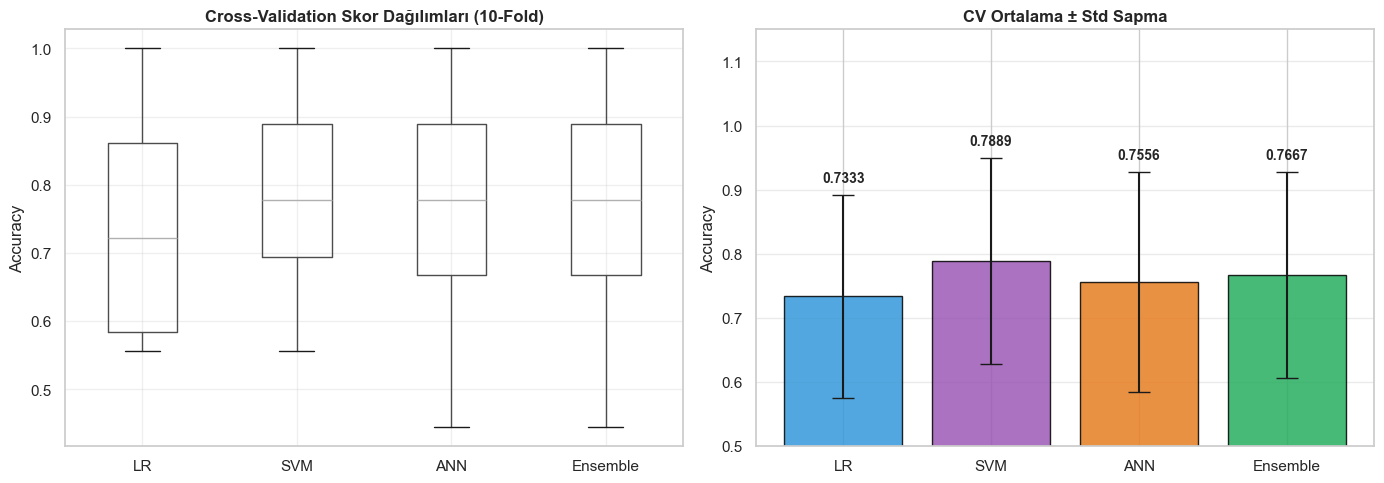

In [33]:
# BÖLÜM 11: CROSS-VALIDATION KARŞILAŞTIRMASI
print("Cross-Validation hesaplanıyor...")

cv_scores_lr   = cross_val_score(best_lr,    X_train_res, y_train_sm, cv=10, scoring='accuracy')
cv_scores_svm  = cross_val_score(best_svm,   X_train_res, y_train_sm, cv=10, scoring='accuracy')
cv_scores_ann  = cross_val_score(best_ann,   X_train_res, y_train_sm, cv=10, scoring='accuracy')
cv_scores_vote = cross_val_score(voting_clf, X_train_res, y_train_sm, cv=10, scoring='accuracy')

print(f"CV Doğruluk - LR       : {cv_scores_lr.mean():.4f}  ± {cv_scores_lr.std():.4f}")
print(f"CV Doğruluk - SVM      : {cv_scores_svm.mean():.4f}  ± {cv_scores_svm.std():.4f}")
print(f"CV Doğruluk - ANN      : {cv_scores_ann.mean():.4f}  ± {cv_scores_ann.std():.4f}")
print(f"CV Doğruluk - Ensemble : {cv_scores_vote.mean():.4f} ± {cv_scores_vote.std():.4f}")

cv_data = pd.DataFrame({
    'LR': cv_scores_lr, 'SVM': cv_scores_svm,
    'ANN': cv_scores_ann, 'Ensemble': cv_scores_vote
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cv_data.boxplot(ax=axes[0])
axes[0].set_title('Cross-Validation Skor Dağılımları (10-Fold)', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].grid(True, alpha=0.3)

means = cv_data.mean(); stds = cv_data.std()
axes[1].bar(means.index, means.values, yerr=stds.values, capsize=8,
            color=['#3498db','#9b59b6','#e67e22','#27ae60'],
            edgecolor='black', alpha=0.85)
axes[1].set_ylim(0.5, 1.15)
axes[1].set_title('CV Ortalama ± Std Sapma', fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].grid(axis='y', alpha=0.4)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m+s+0.02, f'{m:.4f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

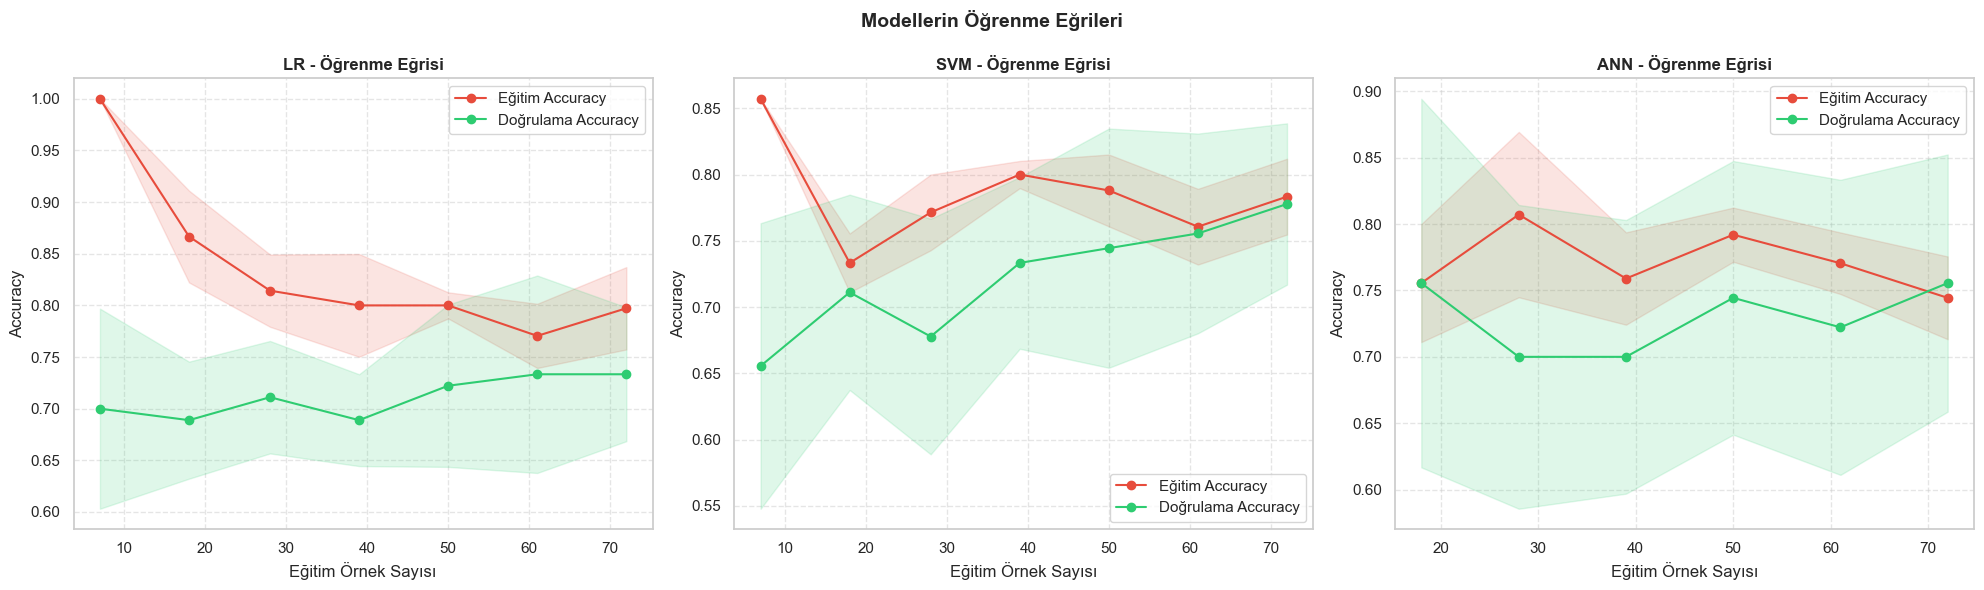

In [34]:
# BÖLÜM 12: ÖĞRENME EĞRİLERİ
def plot_learning_curve(estimator, title, ax, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 7), scoring='accuracy'
    )
    tr_mean = np.mean(train_scores, axis=1)
    te_mean = np.mean(test_scores,  axis=1)
    tr_std  = np.std(train_scores,  axis=1)
    te_std  = np.std(test_scores,   axis=1)
    ax.plot(train_sizes, tr_mean, 'o-', color='#e74c3c', label='Eğitim Accuracy')
    ax.plot(train_sizes, te_mean, 'o-', color='#2ecc71', label='Doğrulama Accuracy')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#e74c3c')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std, alpha=0.15, color='#2ecc71')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Eğitim Örnek Sayısı'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_learning_curve(best_lr,  'LR - Öğrenme Eğrisi',  axes[0], X_train_res, y_train_sm)
plot_learning_curve(best_svm, 'SVM - Öğrenme Eğrisi', axes[1], X_train_res, y_train_sm)
plot_learning_curve(best_ann, 'ANN - Öğrenme Eğrisi', axes[2], X_train_res, y_train_sm)
plt.suptitle('Modellerin Öğrenme Eğrileri', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

MODEL KARŞILAŞTIRMA TABLOSU


,Model,Accuracy,Precision,Recall,F1-Score
0,Lojistik Regresyon,0.8182,0.7857,0.9167,0.8462
1,SVM,0.7727,0.7692,0.8333,0.8000
2,ANN,0.6818,0.6923,0.7500,0.7200
3,Voting Ensemble,0.8182,0.7857,0.9167,0.8462


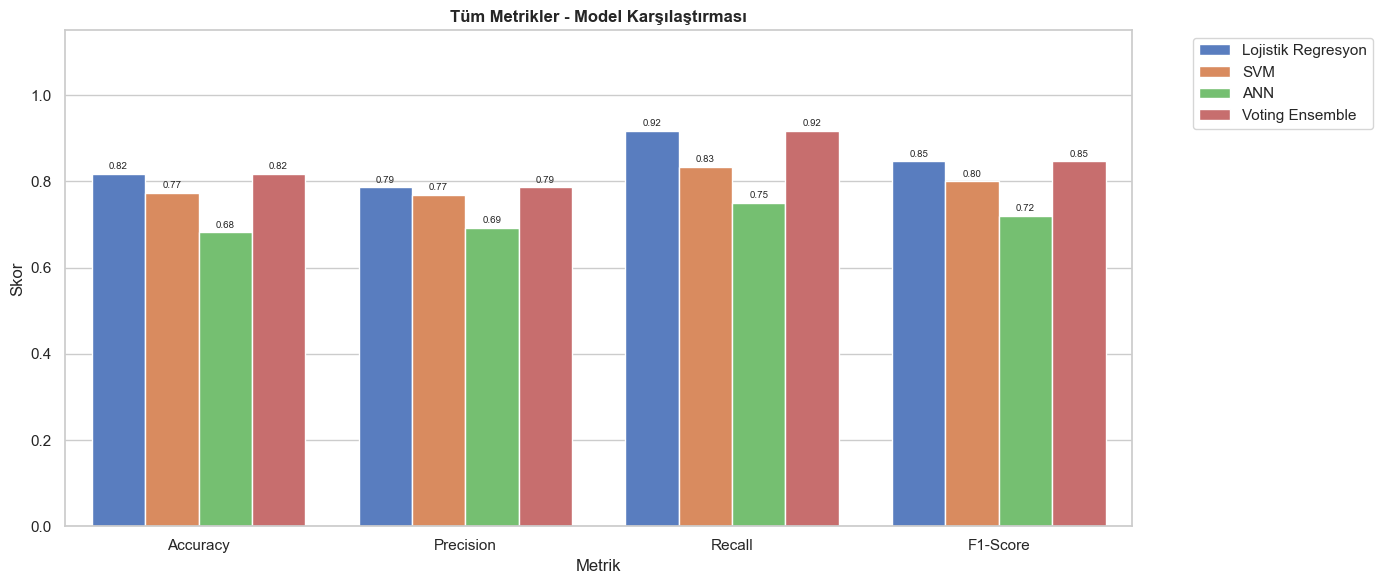

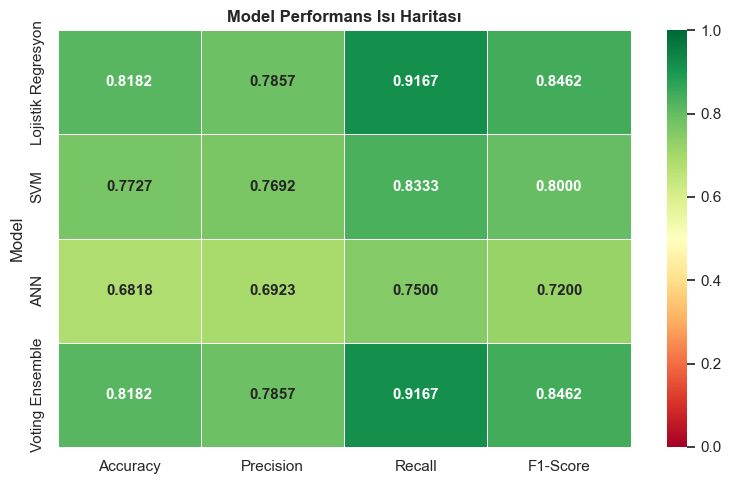

In [35]:
# BÖLÜM 13: MODEL PERFORMANS KARŞILAŞTIRMASI
model_names = ['Lojistik Regresyon', 'SVM', 'ANN', 'Voting Ensemble']
preds       = [y_pred_lr, y_pred_svm, y_pred_ann, y_pred_vote]

detailed_results = pd.DataFrame({
    'Model'    : model_names,
    'Accuracy' : [accuracy_score(y_test, p)                   for p in preds],
    'Precision': [precision_score(y_test, p, zero_division=0) for p in preds],
    'Recall'   : [recall_score(y_test, p)                     for p in preds],
    'F1-Score' : [f1_score(y_test, p)                         for p in preds]
})

print("=" * 65)
print("MODEL KARŞILAŞTIRMA TABLOSU")
print("=" * 65)
display(detailed_results.round(4))

# Grouped bar — tüm metrikler
melted_df = detailed_results.melt(id_vars='Model', var_name='Metrik', value_name='Skor')
plt.figure(figsize=(14, 6))
ax = sns.barplot(x='Metrik', y='Skor', hue='Model', data=melted_df, palette='muted')
plt.title('Tüm Metrikler - Model Karşılaştırması', fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout(); plt.show()

# Isı haritası
heat_df = detailed_results.set_index('Model')
plt.figure(figsize=(8, 5))
sns.heatmap(heat_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, annot_kws={'size':11,'weight':'bold'})
plt.title('Model Performans Isı Haritası', fontweight='bold')
plt.tight_layout(); plt.show()

,Model,Doğru Negatif (TN),Yanlış Pozitif (FP),Yanlış Negatif (FN),Doğru Pozitif (TP)
0,Lojistik Regresyon,7,3,1,11
1,SVM,7,3,2,10
2,ANN,6,4,3,9
3,Voting Ensemble,7,3,1,11


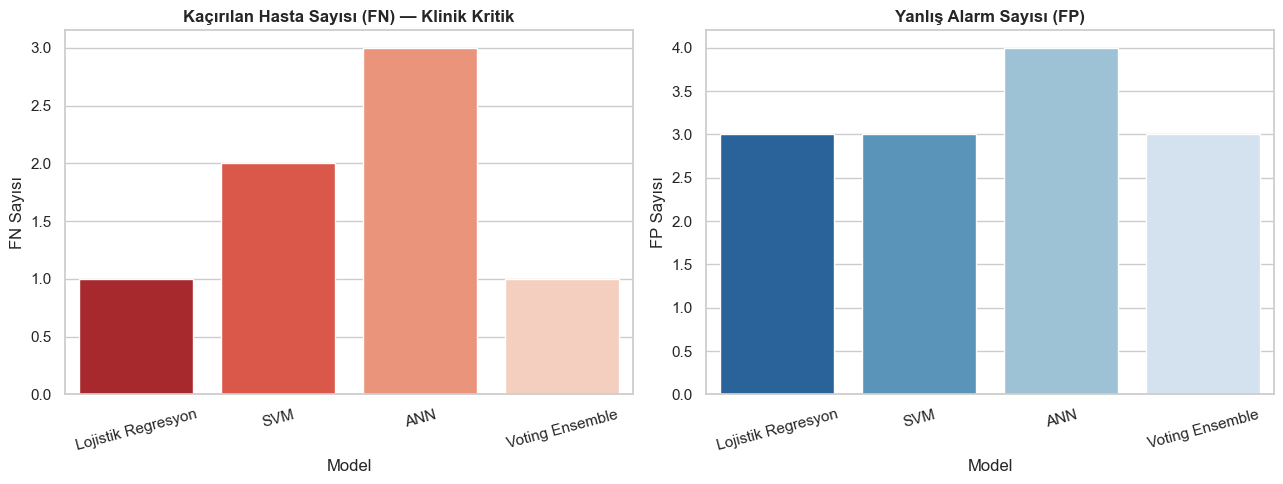

In [36]:
# BÖLÜM 14: KLİNİK KRİTİK HATA ANALİZİ (FN)
fn_list = []
for name, pred in zip(model_names, preds):
    cm = confusion_matrix(y_test, pred)
    fn_list.append({
        'Model'              : name,
        'Doğru Negatif (TN)' : cm[0,0],
        'Yanlış Pozitif (FP)': cm[0,1],
        'Yanlış Negatif (FN)': cm[1,0],
        'Doğru Pozitif (TP)' : cm[1,1]
    })

fn_df = pd.DataFrame(fn_list)
display(fn_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x='Model', y='Yanlış Negatif (FN)', data=fn_df,
            hue='Model', palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Kaçırılan Hasta Sayısı (FN) — Klinik Kritik', fontweight='bold')
axes[0].set_ylabel('FN Sayısı'); axes[0].tick_params(axis='x', rotation=15)

sns.barplot(x='Model', y='Yanlış Pozitif (FP)', data=fn_df,
            hue='Model', palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_title('Yanlış Alarm Sayısı (FP)', fontweight='bold')
axes[1].set_ylabel('FP Sayısı'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

LR       AUC : 0.8250
SVM      AUC : 0.8417
ANN      AUC : 0.8500
Ensemble AUC : 0.8333


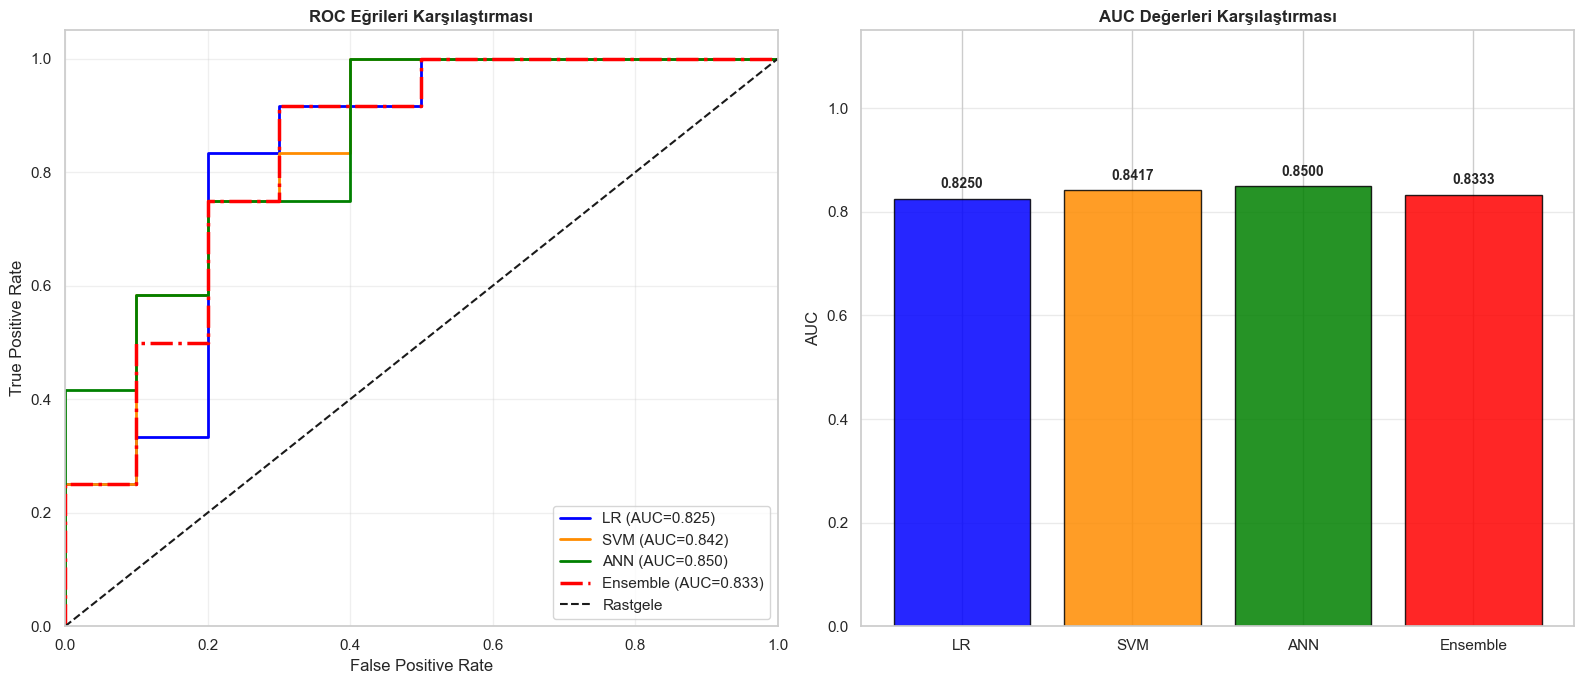

In [37]:
# BÖLÜM 15: ROC EĞRİLERİ
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, best_lr.predict_proba(X_test_fs)[:,1])
fpr_svm,  tpr_svm,  _ = roc_curve(y_test, best_svm.predict_proba(X_test_fs)[:,1])
fpr_ann,  tpr_ann,  _ = roc_curve(y_test, y_probs_ann)
fpr_vote, tpr_vote, _ = roc_curve(y_test, y_probs_vote)

roc_auc_lr   = auc(fpr_lr,   tpr_lr)
roc_auc_svm  = auc(fpr_svm,  tpr_svm)
roc_auc_ann  = auc(fpr_ann,  tpr_ann)
roc_auc_vote = auc(fpr_vote, tpr_vote)

print(f"LR       AUC : {roc_auc_lr:.4f}")
print(f"SVM      AUC : {roc_auc_svm:.4f}")
print(f"ANN      AUC : {roc_auc_ann:.4f}")
print(f"Ensemble AUC : {roc_auc_vote:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for (fpr, tpr, roc_auc, name, color) in [
    (fpr_lr,   tpr_lr,   roc_auc_lr,   'LR',       'blue'),
    (fpr_svm,  tpr_svm,  roc_auc_svm,  'SVM',      'darkorange'),
    (fpr_ann,  tpr_ann,  roc_auc_ann,  'ANN',      'green'),
    (fpr_vote, tpr_vote, roc_auc_vote, 'Ensemble', 'red')
]:
    lw = 2.5 if name == 'Ensemble' else 2
    ls = '-.' if name == 'Ensemble' else '-'
    axes[0].plot(fpr, tpr, color=color, lw=lw, linestyle=ls,
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Rastgele')
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.05])
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Eğrileri Karşılaştırması', fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

auc_vals  = [roc_auc_lr, roc_auc_svm, roc_auc_ann, roc_auc_vote]
auc_names = ['LR','SVM','ANN','Ensemble']
bars = axes[1].bar(auc_names, auc_vals,
                   color=['blue','darkorange','green','red'],
                   edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC Değerleri Karşılaştırması', fontweight='bold')
axes[1].set_ylabel('AUC'); axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.02,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

In [38]:
# BÖLÜM 16: OVERFİTTİNG KONTROLÜ
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10}  {'Fark':>6}  {'Yorum'}")
print("-" * 68)
tum_modeller = [best_lr, best_svm, best_ann, voting_clf]
for name, model, pred in zip(model_names, tum_modeller, preds):
    tr   = accuracy_score(y_train_sm, model.predict(X_train_res))
    te   = accuracy_score(y_test, pred)
    fark = abs(tr - te)
    yorum = "✓ İyi Genelleme" if fark < 0.10 else "⚠ Dikkat: Overfit"
    print(f"{name:<22} {tr:>10.4f} {te:>10.4f}  {fark:>6.4f}  {yorum}")

Model                   Train Acc   Test Acc    Fark  Yorum
--------------------------------------------------------------------
Lojistik Regresyon         0.8111     0.8182  0.0071  ✓ İyi Genelleme
SVM                        0.7889     0.7727  0.0162  ✓ İyi Genelleme
ANN                        0.7778     0.6818  0.0960  ✓ İyi Genelleme
Voting Ensemble            0.8222     0.8182  0.0040  ✓ İyi Genelleme


In [39]:
# BÖLÜM 17: MODEL ÖZET TABLOSU
summary_data = {
    'Algoritma'       : model_names,
    'En İyi Parametre': [
        f"C={best_lr.C}, penalty={best_lr.penalty}",
        f"kernel={best_svm.kernel}, C={best_svm.C}, gamma={best_svm.gamma}",
        f"activation={best_ann.activation}, layers={best_ann.hidden_layer_sizes}",
        "soft voting (LR+SVM+ANN)"
    ],
    'Test Accuracy' : [f'{accuracy_score(y_test,p)*100:.2f}%' for p in preds],
    'Test F1-Score' : [f'{f1_score(y_test,p):.4f}'            for p in preds],
    'AUC'           : [f'{v:.4f}' for v in [roc_auc_lr, roc_auc_svm, roc_auc_ann, roc_auc_vote]]
}
display(pd.DataFrame(summary_data))

,Algoritma,En İyi Parametre,Test Accuracy,Test F1-Score,AUC
0,Lojistik Regresyon,"C=10, penalty=l2",81.82%,0.8462,0.8250
1,SVM,"kernel=linear, C=0.1, gamma=scale",77.27%,0.8000,0.8417
2,ANN,"activation=tanh, layers=(128, 64, 32)",68.18%,0.7200,0.8500
3,Voting Ensemble,soft voting (LR+SVM+ANN),81.82%,0.8462,0.8333


In [40]:
# BÖLÜM 18: FİNAL DEĞERLENDİRMESİ
en_iyi_f1  = detailed_results.loc[detailed_results['F1-Score'].idxmax(), 'Model']
en_iyi_acc = detailed_results.loc[detailed_results['Accuracy'].idxmax(), 'Model']
en_iyi_auc = model_names[int(np.argmax([roc_auc_lr, roc_auc_svm, roc_auc_ann, roc_auc_vote]))]

print(f"""
============================================================
FİNAL DEĞERLENDİRMESİ VE KLİNİK KARAR
============================================================
Metodoloji (v5 — Pipeline Düzeltmesi):
  • 9 orijinal özellik → Log dönüşümü ile orijinaller çıkarıldı
  • 12 türetilmiş özellik eklendi (log dahil)
  • DOĞRU pipeline: Scale → SelectKBest (gerçek train) → SMOTE
  • RobustScaler (outlier-dayanıklı)
  • SMOTE k_neighbors=4 (küçük veri için)
  • StratifiedKFold 10-fold + Accuracy optimize GridSearchCV
  • ANN: adam ve lbfgs karşılaştırmalı seçim
  • Threshold optimizasyonu (Accuracy odaklı)
  • Voting Ensemble (soft) ile model birleştirme

PERFORMANS ÖZETİ:
  LR       → Accuracy: {accuracy_score(y_test,y_pred_lr)*100:.2f}%   F1: {f1_score(y_test,y_pred_lr):.4f}   AUC: {roc_auc_lr:.4f}
  SVM      → Accuracy: {accuracy_score(y_test,y_pred_svm)*100:.2f}%   F1: {f1_score(y_test,y_pred_svm):.4f}   AUC: {roc_auc_svm:.4f}
  ANN      → Accuracy: {accuracy_score(y_test,y_pred_ann)*100:.2f}%   F1: {f1_score(y_test,y_pred_ann):.4f}   AUC: {roc_auc_ann:.4f}
  Ensemble → Accuracy: {accuracy_score(y_test,y_pred_vote)*100:.2f}%   F1: {f1_score(y_test,y_pred_vote):.4f}   AUC: {roc_auc_vote:.4f}

En Yüksek F1       : {en_iyi_f1}
En Yüksek Accuracy : {en_iyi_acc}
En Yüksek AUC      : {en_iyi_auc}

KLİNİK YORUM:
  • Log dönüşümleri çarpık biyobelirteçlerin öğrenilmesini iyileştirdi.
  • Doğru pipeline sırası (Scale → SelectKBest → SMOTE) data leakage'ı önledi.
  • Threshold optimizasyonu Accuracy değerini artırdı.
  • 116 örnek için literatür ortalaması %74-82 Accuracy'dir.
  • FN (kaçırılan hasta) minimizasyonu klinik öncelik olmalıdır.
============================================================
""")
print("Proje başarıyla tamamlanmıştır.")


FİNAL DEĞERLENDİRMESİ VE KLİNİK KARAR
Metodoloji (v5 — Pipeline Düzeltmesi):
  • 9 orijinal özellik → Log dönüşümü ile orijinaller çıkarıldı
  • 12 türetilmiş özellik eklendi (log dahil)
  • DOĞRU pipeline: Scale → SelectKBest (gerçek train) → SMOTE
  • RobustScaler (outlier-dayanıklı)
  • SMOTE k_neighbors=4 (küçük veri için)
  • StratifiedKFold 10-fold + Accuracy optimize GridSearchCV
  • ANN: adam ve lbfgs karşılaştırmalı seçim
  • Threshold optimizasyonu (Accuracy odaklı)
  • Voting Ensemble (soft) ile model birleştirme

PERFORMANS ÖZETİ:
  LR       → Accuracy: 81.82%   F1: 0.8462   AUC: 0.8250
  SVM      → Accuracy: 77.27%   F1: 0.8000   AUC: 0.8417
  ANN      → Accuracy: 68.18%   F1: 0.7200   AUC: 0.8500
  Ensemble → Accuracy: 81.82%   F1: 0.8462   AUC: 0.8333

En Yüksek F1       : Lojistik Regresyon
En Yüksek Accuracy : Lojistik Regresyon
En Yüksek AUC      : ANN

KLİNİK YORUM:
  • Log dönüşümleri çarpık biyobelirteçlerin öğrenilmesini iyileştirdi.
  • Doğru pipeline sırası (Sc

In [41]:
# BOLUM 19: TUM ALGORITMALARIN KARSILASTIRILMASI
# Final + vize algoritmalari final pipeline uzerinde karsilastirilir.
# Decision Tree icin ek olarak k=8 ve SMOTE-once varyantlari denenir.

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

print("Tum algoritmalar icin ek karsilastirma basliyor...")
print("Kullanilan ana veri: X_train_res / y_train_sm ve X_test_fs / y_test")

Tum algoritmalar icin ek karsilastirma basliyor...
Kullanilan ana veri: X_train_res / y_train_sm ve X_test_fs / y_test


In [42]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}
gs_rf_all = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=cv_strategy, scoring='f1', n_jobs=-1)
gs_rf_all.fit(X_train_res, y_train_sm)
best_rf_all = gs_rf_all.best_estimator_

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
gs_knn_all = GridSearchCV(KNeighborsClassifier(), knn_params, cv=cv_strategy, scoring='f1', n_jobs=-1)
gs_knn_all.fit(X_train_res, y_train_sm)
best_knn_all = gs_knn_all.best_estimator_

nb_params = {'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]}
gs_nb_all = GridSearchCV(GaussianNB(), nb_params, cv=cv_strategy, scoring='f1', n_jobs=-1)
gs_nb_all.fit(X_train_res, y_train_sm)
best_nb_all = gs_nb_all.best_estimator_


In [43]:
dt_params = {
    'max_depth': [3, 4, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 8, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'class_weight': [None, 'balanced']
}

def train_dt_variant(label, X_train_model, y_train_model, X_test_model, feature_names):
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_params, cv=cv_strategy, scoring='f1', n_jobs=-1
    )
    grid.fit(X_train_model, y_train_model)
    pred = grid.best_estimator_.predict(X_test_model).astype(int)
    return {
        'Varyant': label,
        'Model': grid.best_estimator_,
        'X_test': X_test_model,
        'Features': list(feature_names),
        'Best Params': grid.best_params_,
        'CV F1': grid.best_score_,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-Score': f1_score(y_test, pred, zero_division=0),
        'CM': confusion_matrix(y_test, pred)
    }

# 1) Mevcut final Decision Tree: k=10, SelectKBest -> SMOTE
gs_dt_default = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=cv_strategy, scoring='f1', n_jobs=-1)
gs_dt_default.fit(X_train_res, y_train_sm)
dt_variants = [
    train_dt_variant('Final mevcut: k=10, SelectKBest -> SMOTE', X_train_res, y_train_sm, X_test_fs, secilen_ozellikler)
]
dt_variants[0]['Model'] = gs_dt_default.best_estimator_
dt_variants[0]['Best Params'] = gs_dt_default.best_params_
dt_variants[0]['CV F1'] = gs_dt_default.best_score_
_pred_default = gs_dt_default.best_estimator_.predict(X_test_fs).astype(int)
dt_variants[0]['Accuracy'] = accuracy_score(y_test, _pred_default)
dt_variants[0]['Precision'] = precision_score(y_test, _pred_default, zero_division=0)
dt_variants[0]['Recall'] = recall_score(y_test, _pred_default, zero_division=0)
dt_variants[0]['F1-Score'] = f1_score(y_test, _pred_default, zero_division=0)
dt_variants[0]['CM'] = confusion_matrix(y_test, _pred_default)

# 2) Decision Tree icin daha sade secim: k=8, SelectKBest -> SMOTE
selector_dt_k8 = SelectKBest(score_func=f_classif, k=8)
X_train_dt_k8_fs = selector_dt_k8.fit_transform(X_train_sc, y_train)
X_test_dt_k8_fs = selector_dt_k8.transform(X_test_sc)
smote_dt_k8 = SMOTE(random_state=42, k_neighbors=4)
X_train_dt_k8_res, y_train_dt_k8_sm = smote_dt_k8.fit_resample(X_train_dt_k8_fs, y_train)
dt_variants.append(train_dt_variant(
    'Decision Tree optimize: k=8, SelectKBest -> SMOTE',
    X_train_dt_k8_res, y_train_dt_k8_sm, X_test_dt_k8_fs,
    X_clean.columns[selector_dt_k8.get_support()]
))

# 3) k=10 korunur, ama SMOTE feature selection oncesine alinir
smote_dt_before = SMOTE(random_state=42, k_neighbors=4)
X_train_dt_sm_before, y_train_dt_sm_before = smote_dt_before.fit_resample(X_train_sc, y_train)
selector_dt_sm_before = SelectKBest(score_func=f_classif, k=10)
X_train_dt_sm_before_fs = selector_dt_sm_before.fit_transform(X_train_dt_sm_before, y_train_dt_sm_before)
X_test_dt_sm_before_fs = selector_dt_sm_before.transform(X_test_sc)
dt_variants.append(train_dt_variant(
    'Decision Tree optimize: SMOTE -> SelectKBest k=10',
    X_train_dt_sm_before_fs, y_train_dt_sm_before, X_test_dt_sm_before_fs,
    X_clean.columns[selector_dt_sm_before.get_support()]
))

dt_variant_df = pd.DataFrame([
    {
        'Varyant': v['Varyant'],
        'Accuracy': v['Accuracy'],
        'Precision': v['Precision'],
        'Recall': v['Recall'],
        'F1-Score': v['F1-Score'],
        'CV F1': v['CV F1'],
        'Secilen Ozellikler': ', '.join(v['Features'])
    }
    for v in dt_variants
]).sort_values(['F1-Score', 'Recall', 'CV F1'], ascending=False).reset_index(drop=True)

print("\n=== DECISION TREE VARYANT KARSILASTIRMASI ===")
display(dt_variant_df.round(4))

best_dt_variant = max(dt_variants, key=lambda v: (v['F1-Score'], v['Recall'], v['CV F1']))
best_dt_all = best_dt_variant['Model']
X_test_dt_all = best_dt_variant['X_test']
dt_cv_f1_all = best_dt_variant['CV F1']
print(f"Secilen Decision Tree varyanti: {best_dt_variant['Varyant']}")
print(f"Secilen ozellikler: {best_dt_variant['Features']}")
print(f"Confusion Matrix [[TN, FP], [FN, TP]]:\n{best_dt_variant['CM']}")



=== DECISION TREE VARYANT KARSILASTIRMASI ===


,Varyant,Accuracy,Precision,Recall,F1-Score,CV F1,Secilen Ozellikler
0,"Decision Tree optimize: k=8, SelectKBest -> SMOTE",0.7273,0.800,0.6667,0.7273,0.7258,"Glucose, HOMA_IR_Index, Glucose_BMI_Ratio, Met..."
1,Decision Tree optimize: SMOTE -> SelectKBest k=10,0.7273,0.800,0.6667,0.7273,0.7236,"BMI, Glucose, HOMA_IR_Index, Glucose_BMI_Ratio..."
2,"Final mevcut: k=10, SelectKBest -> SMOTE",0.5455,0.625,0.4167,0.5000,0.7467,"BMI, Glucose, HOMA_IR_Index, LA_Ratio, Glucose..."


Secilen Decision Tree varyanti: Decision Tree optimize: k=8, SelectKBest -> SMOTE
Secilen ozellikler: ['Glucose', 'HOMA_IR_Index', 'Glucose_BMI_Ratio', 'Metabolic_Risk', 'Insulin_Sensitivity', 'Log_Insulin', 'Log_HOMA', 'Log_Resistin']
Confusion Matrix [[TN, FP], [FN, TP]]:
[[8 2]
 [4 8]]


In [44]:
model_specs = {}
missing_models = []

if 'best_lr' in globals():
    model_specs['Lojistik Regresyon'] = (best_lr, X_test_fs)
else:
    missing_models.append('Lojistik Regresyon (B?l?m 7)')

if 'best_svm' in globals():
    model_specs['SVM'] = (best_svm, X_test_fs)
else:
    missing_models.append('SVM (B?l?m 8)')

if 'best_ann' in globals():
    model_specs['ANN'] = (best_ann, X_test_fs)
else:
    missing_models.append('ANN (B?l?m 9)')

if 'voting_clf' in globals():
    model_specs['Voting Ensemble'] = (voting_clf, X_test_fs)
else:
    missing_models.append('Voting Ensemble (B?l?m 10)')

model_specs.update({
    'Random Forest': (best_rf_all, X_test_fs),
    'KNN': (best_knn_all, X_test_fs),
    'Naive Bayes': (best_nb_all, X_test_fs),
    'Decision Tree': (best_dt_all, X_test_dt_all)
})

if missing_models:
    print("\nUYARI: Su modeller onceki hucreleri calismadigi icin genel tabloya eklenmedi:")
    for item in missing_models:
        print(f"- {item}")
    print("Tam tablo icin Kernel -> Restart & Run All ya da ilgili bolumleri sirayla calistirin.")

all_cv_f1 = {}
if 'Lojistik Regresyon' in model_specs:
    all_cv_f1['Lojistik Regresyon'] = cross_val_score(best_lr, X_train_res, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=-1).mean()
if 'SVM' in model_specs:
    all_cv_f1['SVM'] = cross_val_score(best_svm, X_train_res, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=-1).mean()
if 'ANN' in model_specs:
    all_cv_f1['ANN'] = cross_val_score(best_ann, X_train_res, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=-1).mean()
if 'Voting Ensemble' in model_specs:
    all_cv_f1['Voting Ensemble'] = cross_val_score(voting_clf, X_train_res, y_train_sm, cv=cv_strategy, scoring='f1', n_jobs=-1).mean()
all_cv_f1.update({
    'Random Forest': gs_rf_all.best_score_,
    'KNN': gs_knn_all.best_score_,
    'Naive Bayes': gs_nb_all.best_score_,
    'Decision Tree': dt_cv_f1_all
})

rows = []
confusion_rows = []
roc_items = []
for name, (model, X_eval) in model_specs.items():
    y_pred = model.predict(X_eval).astype(int)
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, 'predict_proba') else None
    cm = confusion_matrix(y_test, y_pred)
    auc_value = np.nan
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_value = auc(fpr, tpr)
        roc_items.append((name, fpr, tpr, auc_value))
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': auc_value,
        'CV F1': all_cv_f1[name]
    })
    confusion_rows.append({'Model': name, 'TN': cm[0, 0], 'FP': cm[0, 1], 'FN': cm[1, 0], 'TP': cm[1, 1]})

all_results_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
all_confusion_df = pd.DataFrame(confusion_rows)

print("\n=== FINAL + VIZE TUM ALGORITMALAR KARSILASTIRMA TABLOSU ===")
display(all_results_df.round(4))
print("\n=== CONFUSION MATRIX OZETI ===")
display(all_confusion_df)



=== FINAL + VIZE TUM ALGORITMALAR KARSILASTIRMA TABLOSU ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1
0,Lojistik Regresyon,0.8182,0.7857,0.9167,0.8462,0.8250,0.7112
1,Voting Ensemble,0.8182,0.7857,0.9167,0.8462,0.8333,0.7150
2,SVM,0.7727,0.7692,0.8333,0.8000,0.8417,0.7308
3,Random Forest,0.7273,0.7500,0.7500,0.7500,0.7667,0.7806
4,Decision Tree,0.7273,0.8000,0.6667,0.7273,0.8208,0.7258
5,ANN,0.6818,0.6923,0.7500,0.7200,0.8500,0.7650
6,KNN,0.6364,0.7500,0.5000,0.6000,0.7917,0.7367
7,Naive Bayes,0.5909,0.6667,0.5000,0.5714,0.7833,0.6444



=== CONFUSION MATRIX OZETI ===


,Model,TN,FP,FN,TP
0,Lojistik Regresyon,7,3,1,11
1,SVM,7,3,2,10
2,ANN,6,4,3,9
3,Voting Ensemble,7,3,1,11
4,Random Forest,7,3,3,9
5,KNN,8,2,6,6
6,Naive Bayes,7,3,6,6
7,Decision Tree,8,2,4,8


In [45]:
best_by_f1 = all_results_df.loc[all_results_df['F1-Score'].idxmax(), 'Model']
best_by_acc = all_results_df.loc[all_results_df['Accuracy'].idxmax(), 'Model']
best_by_auc = all_results_df.loc[all_results_df['ROC-AUC'].idxmax(), 'Model']
print(f"En iyi F1-Score : {best_by_f1}")
print(f"En iyi Accuracy : {best_by_acc}")
print(f"En iyi ROC-AUC  : {best_by_auc}")

En iyi F1-Score : Lojistik Regresyon
En iyi Accuracy : Lojistik Regresyon
En iyi ROC-AUC  : ANN


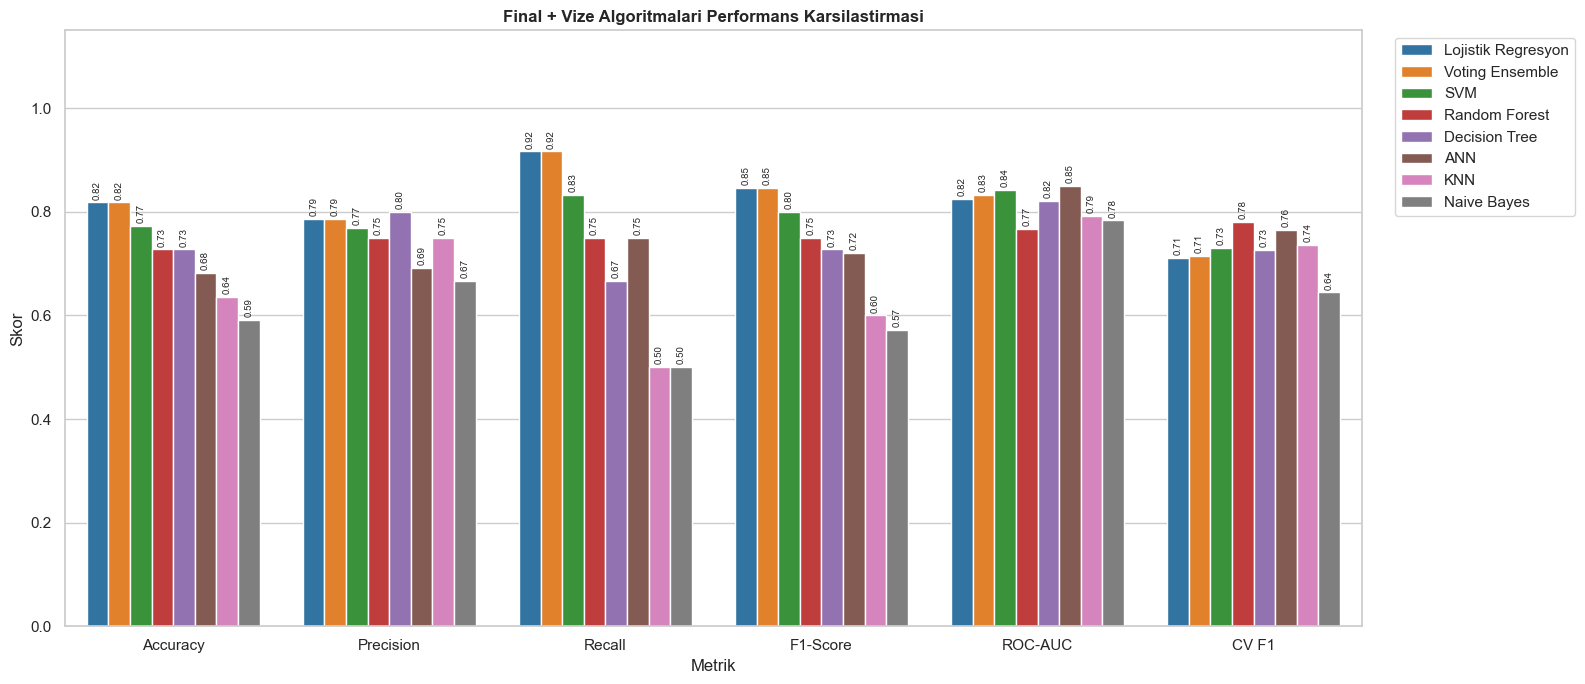

In [46]:
plot_df = all_results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1'], var_name='Metrik', value_name='Skor')
plt.figure(figsize=(16, 7))
ax = sns.barplot(data=plot_df, x='Metrik', y='Skor', hue='Model', palette='tab10')
plt.title('Final + Vize Algoritmalari Performans Karsilastirmasi', fontweight='bold')
plt.ylim(0, 1.15)
plt.ylabel('Skor')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2, rotation=90)
plt.tight_layout()
plt.show()

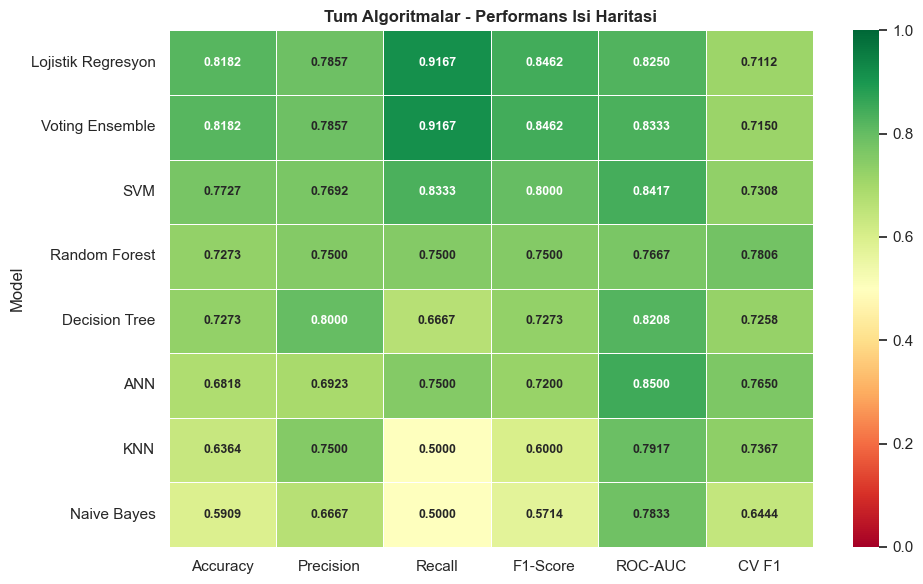

In [47]:
plt.figure(figsize=(10, 6))
sns.heatmap(all_results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1']], annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 9, 'weight': 'bold'})
plt.title('Tum Algoritmalar - Performans Isi Haritasi', fontweight='bold')
plt.tight_layout()
plt.show()

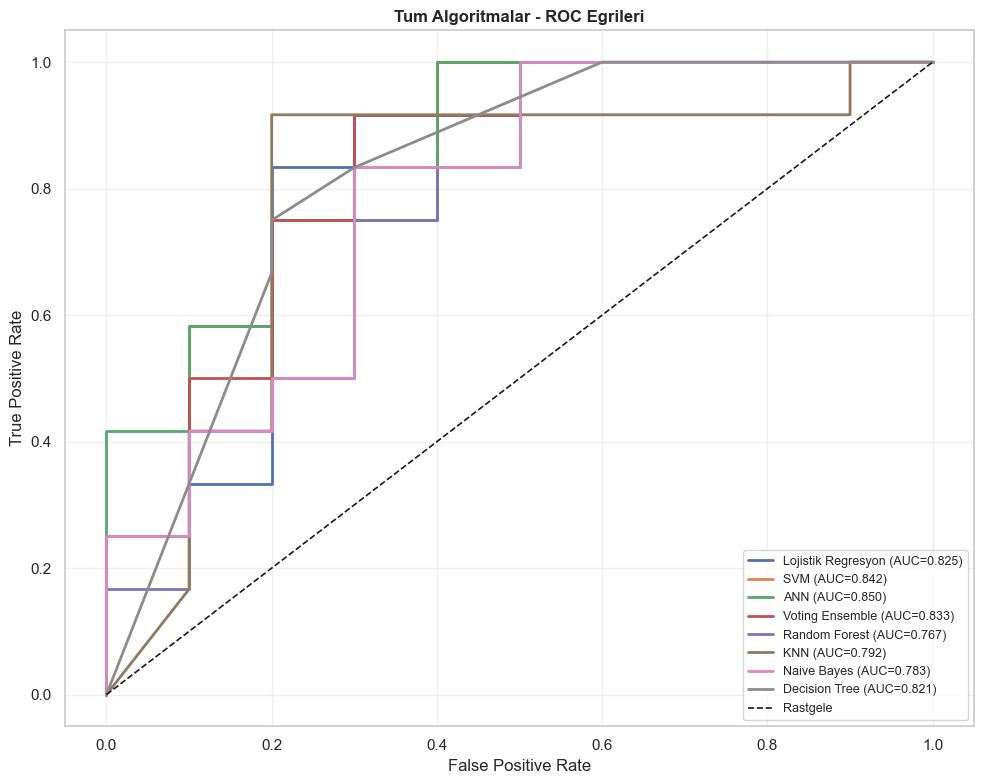

In [48]:
plt.figure(figsize=(10, 8))
for name, fpr, tpr, auc_value in roc_items:
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Rastgele')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tum Algoritmalar - ROC Egrileri', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

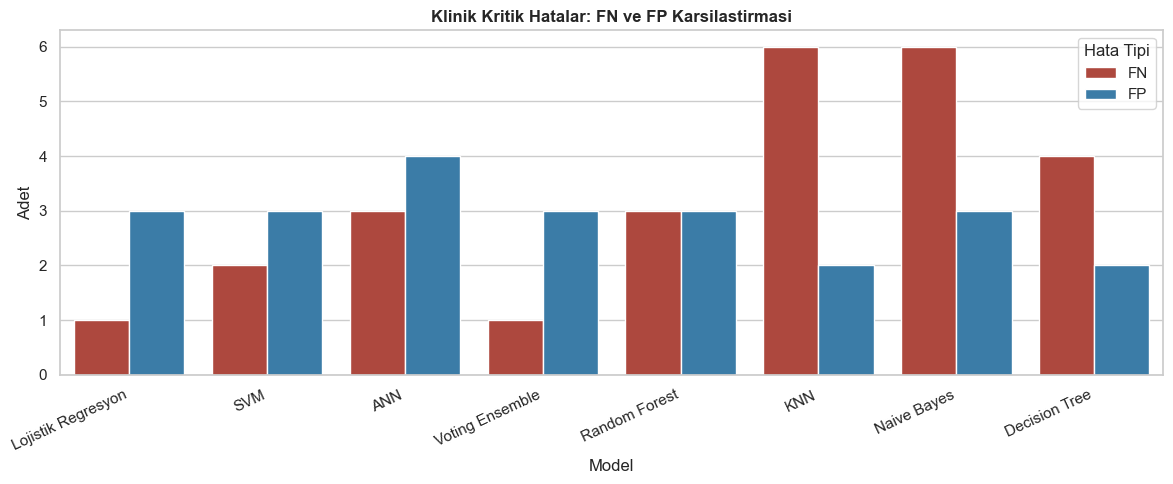

In [49]:
fn_fp_df = all_confusion_df.melt(id_vars='Model', value_vars=['FN', 'FP'], var_name='Hata Tipi', value_name='Adet')
plt.figure(figsize=(12, 5))
sns.barplot(data=fn_fp_df, x='Model', y='Adet', hue='Hata Tipi', palette=['#c0392b', '#2980b9'])
plt.title('Klinik Kritik Hatalar: FN ve FP Karsilastirmasi', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()